# import

In [1]:
import pandas as pd
import numpy as np
import warnings
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import xgboost as xgb

# 경고 메시지 끄기 (깔끔한 출력을 위해)
warnings.filterwarnings('ignore')


# 데이터 로드 

In [2]:
train_path = r"..\datasets\train.csv"
test_path  = r"..\datasets\test.csv"

try:
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    print(f"학습 세트: {train.shape}")
    print(f"테스트 세트: {test.shape}")
except FileNotFoundError:
    print("❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요.")


학습 세트: (748, 46)
테스트 세트: (814, 45)


# 데이터 통합

정석은 학습 세트와 테스트 세트를 먼저 분할한 후 전처리를 진행하지만, 

단순 모델의 성능을 올리기 위해 학습 세트와 테스트 세트 데이터를 합쳐서 한꺼번에 전처리 후 분할하는 방식 시도

In [3]:
# 나중에 분리하기 위해 꼬리표(Label) 붙이기
train['dataset'] = 'train'
test['dataset'] = 'test'

# 위아래로 합치기
df_all = pd.concat([train, test], ignore_index=True)

print(f"합쳐진 데이터 크기: {df_all.shape}\n")
# 잘 합쳐졌는지 확인
print(df_all['dataset'].value_counts())


합쳐진 데이터 크기: (1562, 47)

dataset
test     814
train    748
Name: count, dtype: int64


In [4]:
# =========================================================
# [중간 점검] 현재 데이터프레임의 결측치 현황 확인
# =========================================================

print("\n" + "=" * 60)
print("🔍 결측치(NaN) 보유 컬럼 및 개수 확인")
print("=" * 60)

# 1. 컬럼별 결측치 개수 계산
null_counts = df_all.isnull().sum()

# 2. 결측치가 1개라도 있는 컬럼만 필터링
null_cols = null_counts[null_counts > 0].sort_values(ascending=False)

if len(null_cols) > 0:
    print(f"⚠️ 총 {len(null_cols)}개 컬럼에서 결측치가 발견되었습니다.")
    print("-" * 60)
    print(f"{'컬럼명':<30} | {'결측치 개수':<10} | {'비율(%)'}")
    print("-" * 60)
    
    for col_name, count in null_cols.items():
        ratio = (count / len(df_all)) * 100
        print(f"{col_name:<30} | {count:<10} | {ratio:.2f}%")
else:
    print("✅ 현재 데이터프레임에 결측치가 하나도 없습니다! (Clean)")

print("=" * 60 + "\n")



🔍 결측치(NaN) 보유 컬럼 및 개수 확인
⚠️ 총 19개 컬럼에서 결측치가 발견되었습니다.
------------------------------------------------------------
컬럼명                            | 결측치 개수     | 비율(%)
------------------------------------------------------------
contest_award                  | 1562       | 100.00%
idea_contest                   | 1562       | 100.00%
contest_participation          | 1556       | 99.62%
class4                         | 1554       | 99.49%
class3                         | 1502       | 96.16%
previous_class_6               | 1261       | 80.73%
previous_class_7               | 1261       | 80.73%
previous_class_8               | 1261       | 80.73%
previous_class_4               | 1261       | 80.73%
previous_class_5               | 1261       | 80.73%
previous_class_3               | 1261       | 80.73%
class2                         | 1151       | 73.69%
completed                      | 814        | 52.11%
major1_2                       | 622        | 39.82%
completed_semester          


🔍 [긴급 진단] previous_class 6형제 중요도 & 상관관계 분석

📊 1) Target(completed)과의 상관계수 (절댓값 순)
--------------------------------------------------
previous_class_3_enc    0.129775
previous_class_4_enc    0.091563
previous_class_8_enc    0.074715
previous_class_5_enc    0.040367
previous_class_7_enc    0.034480
previous_class_6_enc    0.009579
Name: completed, dtype: float64

🌲 2) Random Forest 변수 중요도 (Gini Importance)
--------------------------------------------------
previous_class_8    0.401269
previous_class_7    0.233743
previous_class_6    0.169646
previous_class_5    0.085640
previous_class_4    0.057135
previous_class_3    0.052566
dtype: float64


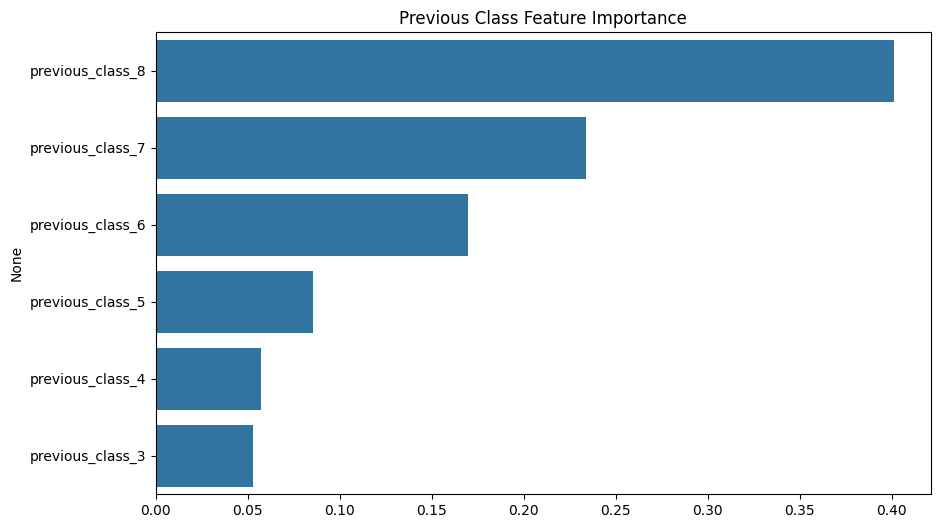

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 분석 대상 변수 리스트
target_features = [
    'previous_class_3', 'previous_class_4', 'previous_class_5', 
    'previous_class_6', 'previous_class_7', 'previous_class_8'
]

print("\n" + "=" * 70)
print("🔍 [긴급 진단] previous_class 6형제 중요도 & 상관관계 분석")
print("=" * 70)

# 1. 분석을 위한 임시 데이터셋 준비 (Train 데이터만 사용!)
# Test 데이터는 정답(completed)이 없으므로 분석 불가
temp_df = df_all[df_all['dataset'] == 'train'].copy()

# 2. 간단 전처리 (결측치 채우기 + 문자열로 변환)
for col in target_features:
    if col in temp_df.columns:
        temp_df[col] = temp_df[col].fillna('Unknown').astype(str)
    else:
        print(f"⚠️ {col} 컬럼이 없습니다.")

# 3. 인코딩 (Random Forest용 레이블 인코딩)
# 다중선택 텍스트라도 일단 하나의 카테고리로 보고 숫자로 바꿈 (간이 분석용)
le = LabelEncoder()
encoded_features = []

for col in target_features:
    if col in temp_df.columns:
        # 인코딩된 컬럼명 생성
        new_col = f"{col}_enc"
        temp_df[new_col] = le.fit_transform(temp_df[col])
        encoded_features.append(new_col)

# ---------------------------------------------------------
# A. 상관계수 (Correlation) 분석
# ---------------------------------------------------------
print("\n📊 1) Target(completed)과의 상관계수 (절댓값 순)")
print("-" * 50)

# 상관계수 계산
corr_matrix = temp_df[encoded_features + ['completed']].corr()
target_corr = corr_matrix['completed'].drop('completed') # 자기 자신 제외

# 절댓값 기준으로 정렬해서 출력
print(target_corr.abs().sort_values(ascending=False))


# ---------------------------------------------------------
# B. 변수 중요도 (Feature Importance) - Random Forest
# ---------------------------------------------------------
print("\n🌲 2) Random Forest 변수 중요도 (Gini Importance)")
print("-" * 50)

# 모델 학습 (가볍게 100그루만)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
X = temp_df[encoded_features]
y = temp_df['completed']

rf.fit(X, y)

# 중요도 추출
importances = pd.Series(rf.feature_importances_, index=target_features)
sorted_importances = importances.sort_values(ascending=False)

print(sorted_importances)

# (선택) 시각화가 필요하면 주석 해제
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)
plt.title('Previous Class Feature Importance')
plt.show()

print("=" * 70 + "\n")


# 데이터 전처리 - 변수 제거(1)

1. 수동 제거<br>
[ID] -> 고유 식별자<br>
[generation], [nationality] -> 상수<br>
[interested_company], [incumbents_lecture_scale_reason] -> 서술형 

2. 결측치 개수가 전체 데이터의 80% 이상인 8개의 피처 제거<br>
[previous_class_6], [previous_class_7], [previous_class_8]는 결측치가 80% 이상이지만 변수 중요도 평가에서 유의미하다고 판단하여 제거하지 않음.

In [6]:
# =========================================================
# 데이터 전처리 - 변수 제거 (수정됨)
# =========================================================

# 1. 수동으로 지정한 삭제 컬럼 (5개)  
manual_drop_cols = ['ID', 'generation', 'nationality', 'interested_company', 'incumbents_lecture_scale_reason']

# 2. 결측치가 80% 이상인 컬럼 자동 찾기 (기준 완화: 0.5 -> 0.8)
missing_rate = df_all.isnull().mean()
high_missing_cols = missing_rate[missing_rate >= 0.8].index.tolist()

# 3. 보호해야 할 컬럼 설정 (삭제 면제 리스트)
# - 기본 보호: 타겟변수(completed), 데이터구분(dataset)
# - 추가 보호: 결측이 많아도 중요도가 높았던 변수들(previous_class 시리즈)
protect_cols = [
    'completed', 'dataset', 
    'previous_class_6', 'previous_class_7', 'previous_class_8'
]

# 실제로 자동 삭제될 리스트 (보호 대상 제외)
real_high_missing_cols = [c for c in high_missing_cols if c not in protect_cols]

# 4. 삭제 대상 통합 (중복 제거)
# 수동 삭제 대상과 자동 삭제 대상을 합침
final_remove_list = list(set(manual_drop_cols + real_high_missing_cols))

# 삭제 실행
df_all = df_all.drop(columns=final_remove_list)

# 결과 출력
print(f"🗑️ [수동 삭제] 지정된 5개 변수:") 
print(f"   -> {manual_drop_cols}")
print("-" * 50)
print(f"🗑️ [자동 삭제] 결측치 80% 이상 (보호변수 제외 총 8개):")
print(f"   -> {sorted(real_high_missing_cols)}")
print("-" * 50)
print(f"🛡️ [보호됨] 결측치 80% 이상이지만 삭제되지 않은 변수:")
# 80% 이상인데 보호 목록에 있어서 살아남은 애들만 출력
saved_cols = [c for c in high_missing_cols if c in protect_cols]
print(f"   -> {saved_cols}")
print("-" * 50)
print(f"✅ 총 삭제된 컬럼 수: {len(final_remove_list)}개")
print(f"📊 현재 남은 컬럼 수: {df_all.shape[1]}")


🗑️ [수동 삭제] 지정된 5개 변수:
   -> ['ID', 'generation', 'nationality', 'interested_company', 'incumbents_lecture_scale_reason']
--------------------------------------------------
🗑️ [자동 삭제] 결측치 80% 이상 (보호변수 제외 총 8개):
   -> ['class3', 'class4', 'contest_award', 'contest_participation', 'idea_contest', 'previous_class_3', 'previous_class_4', 'previous_class_5']
--------------------------------------------------
🛡️ [보호됨] 결측치 80% 이상이지만 삭제되지 않은 변수:
   -> ['previous_class_6', 'previous_class_7', 'previous_class_8']
--------------------------------------------------
✅ 총 삭제된 컬럼 수: 13개
📊 현재 남은 컬럼 수: 34


# 데이터 전처리 - 결측치/이상치 처리(2)

수치형 변수 결측치/이상치 처리

[completed_semester] 

-> 중앙값으로 대체 후 데이터 타입을 연속형에서 정수형으로 변환.

값이 0인 데이터가 하나 있었지만, ‘job’==‘직장인’, ‘major1_1’==‘기타’, ‘school1’==0인 것으로 보아, 대학 진학없이 바로 취직한 특이 케이스로 간주하여 이상치 처리 X

In [7]:
target_col = 'completed_semester'

# 1. 이상치 확인 (20 이상인 값들 미리 보기)
outlier_mask = df_all[target_col] >= 20
outliers = df_all.loc[outlier_mask, target_col].tolist()

print(f"🔍 [확인] 값이 20 이상인 이상치 목록 ({len(outliers)}개):")
print(f"   -> {outliers}")

# 2. 이상치 처리: NaN으로 변경 (그래야 중앙값 계산 등에서 제외됨)
# (0인 값은 정상 데이터이므로 건드리지 않음)
df_all.loc[outlier_mask, target_col] = np.nan

# 3. 중앙값 계산 (학습용 데이터 기준!)
median_val = df_all.loc[df_all['dataset'] == 'train', target_col].median()

# 4. 결측치(NaN)를 중앙값으로 채우기 & 정수 변환
df_all[target_col] = df_all[target_col].fillna(median_val).astype(int)

print("-" * 50)
print(f"✅ '{target_col}' 결측치 및 이상치 처리 완료")
print(f"   - 대체된 중앙값: {median_val}\n")
print(df_all[target_col].describe())


🔍 [확인] 값이 20 이상인 이상치 목록 (3개):
   -> [2020.02, 20241.0, 20241.0]
--------------------------------------------------
✅ 'completed_semester' 결측치 및 이상치 처리 완료
   - 대체된 중앙값: 6.0

count    1562.000000
mean        6.117157
std         1.742479
min         0.000000
25%         5.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: completed_semester, dtype: float64


범주형 변수 결측치/이상치 처리 

[major type]에서 '단일 전공공학 (컴퓨터 공학 제외)'라는 이상치 발견 

In [8]:
# 점검할 변수 리스트 (이진 변수 5인방)
check_targets = [
    'major type', 
    're_registration', 
    'project_type', 
    'incumbents_level', 
    'major_data'
]

print("🔍 [정밀 점검] 이진 변수 값 종류 확인")
print("=" * 60)

for col in check_targets:
    if col in df_all.columns:
        # 고유값 추출 (NaN 포함)
        uni_vals = df_all[col].unique()
        # 값 개수 카운트 (어떤 게 주류이고 어떤 게 이상치인지 파악용)
        val_counts = df_all[col].value_counts(dropna=False)
        
        print(f"📌 [{col}]")
        print(f"   - 고유값 목록 ({len(uni_vals)}개): {uni_vals}")
        print(f"   - 값 분포:\n{val_counts}")
        print("-" * 60)
    else:
        print(f"⚠️ {col} 컬럼이 존재하지 않습니다.")

print("점검 완료. 이상한 값이 보이면 매핑 딕셔너리에 추가하거나 전처리 단계에서 수정하세요.")


🔍 [정밀 점검] 이진 변수 값 종류 확인
📌 [major type]
   - 고유값 목록 (4개): ['복수 전공 ( 다중전공, 이중전공 포함 )' '단일 전공' nan '단일 전공공학 (컴퓨터 공학 제외)']
   - 값 분포:
major type
단일 전공                      856
복수 전공 ( 다중전공, 이중전공 포함 )    609
NaN                         96
단일 전공공학 (컴퓨터 공학 제외)          1
Name: count, dtype: int64
------------------------------------------------------------
📌 [re_registration]
   - 고유값 목록 (2개): ['아니요' '예']
   - 값 분포:
re_registration
아니요    1261
예       301
Name: count, dtype: int64
------------------------------------------------------------
📌 [project_type]
   - 고유값 목록 (2개): ['팀' '개인']
   - 값 분포:
project_type
팀     1103
개인     459
Name: count, dtype: int64
------------------------------------------------------------
📌 [incumbents_level]
   - 고유값 목록 (2개): ['시니어 (10년차 ~)' '주니어 (0~3년차)']
   - 값 분포:
incumbents_level
주니어 (0~3년차)     1074
시니어 (10년차 ~)     488
Name: count, dtype: int64
------------------------------------------------------------
📌 [major_data]
   - 고유값 목록 (2개): [False  True]
   - 값 

[major1_1] → ‘Unknown’으로 대체

[major type] → major1_1, major1_2 값이 둘 다 존재한다면 '복수 전공 ( 다중전공, 이중전공 포함 )', 그렇지 않다면 '단일 전공'으로 대체

'단일 전공공학 (컴퓨터 공학 제외)' 이상치를 '단일 전공'으로 대체

[major_field] → ‘Unknown’으로 대체

[major1_2] → ‘없음’으로 대체

In [9]:
# 처리할 범주형 변수들
cat_cols = ['major1_1', 'major1_2', 'major_field', 'major type']

print("📊 [처리 전] 범주형 변수 결측치 개수:")
print(df_all[cat_cols].isnull().sum())


# ---------------------------------------------------------
# (0) [추가] 이상치 선제적 처리 (Cleaning)
# ---------------------------------------------------------
# 이상한 값('단일 전공공학...')을 미리 '단일 전공'으로 고쳐놓습니다.
# 이렇게 하면 아래 함수나 나중에 인코딩할 때 별도 예외처리가 필요 없습니다.
dirty_val = '단일 전공공학 (컴퓨터 공학 제외)'
if dirty_val in df_all['major type'].values:
    df_all['major type'] = df_all['major type'].replace(dirty_val, '단일 전공')
    print(f"✅ 이상치 수정 완료: '{dirty_val}' -> '단일 전공'")


# ---------------------------------------------------------
# (1) major1_1 & major_field: 단순 결측 채우기
# ---------------------------------------------------------
df_all['major1_1'] = df_all['major1_1'].fillna('Unknown')
df_all['major_field'] = df_all['major_field'].fillna('Unknown')


# ---------------------------------------------------------
# (2) major type: 결측치만 채우기 (기존 값 유지!)
# ---------------------------------------------------------
# 이미 값이 있으면 그대로 두고, 비어있는 경우에만 로직 적용
def fill_major_type(row):
    # 이미 값이 있으면 건드리지 않음 (아까 고친 '단일 전공'도 여기서 걸러져서 그대로 유지됨)
    if pd.notna(row['major type']):
        return row['major type']
    
    # 값이 비어있을 때만 추론:
    # major1_2가 있으면(값이 있고 '없음'이 아니면) -> 복수 전공으로 추정
    if pd.notna(row['major1_2']) and row['major1_2'] != '없음':
        return '복수 전공 ( 다중전공, 이중전공 포함 )' # (원래 값 유지)
    else:
        return '단일 전공'

df_all['major type'] = df_all.apply(fill_major_type, axis=1)


# ---------------------------------------------------------
# (3) major1_2: 마지막으로 채우기
# ---------------------------------------------------------
# 위에서 major type 채울 때 major1_2 값을 참고했으므로, 이제 안전하게 '없음'으로 채움
df_all['major1_2'] = df_all['major1_2'].fillna('없음')


print("-" * 50)
print("✅ [처리 후] 범주형 변수 결측치 개수:")
print(df_all[cat_cols].isnull().sum())


📊 [처리 전] 범주형 변수 결측치 개수:
major1_1        93
major1_2       622
major_field     97
major type      96
dtype: int64
✅ 이상치 수정 완료: '단일 전공공학 (컴퓨터 공학 제외)' -> '단일 전공'
--------------------------------------------------
✅ [처리 후] 범주형 변수 결측치 개수:
major1_1       0
major1_2       0
major_field    0
major type     0
dtype: int64


# 데이터 전처리 - 범주형 변수 인코딩(3)

[major type], [re_registration], [project_type], [major_data], [incumbents_level]

-> 이진값(카테고리가 2개)을 가지는 5개의 변수: 레이블 인코딩

In [10]:
# ---------------------------------------------------------
# 이진 변수(Binary) 레이블 인코딩
# ---------------------------------------------------------

binary_mappings = {
    'major type': {
        '단일 전공': 0, 
        '복수 전공 ( 다중전공, 이중전공 포함 )': 1
    },
    're_registration': {'아니요': 0, '예': 1},
    'project_type': {'개인': 0, '팀': 1},
    'incumbents_level': {'주니어 (0~3년차)': 0, '시니어 (10년차 ~)': 1}
}

cols_to_map = ['major type', 're_registration', 'project_type', 'incumbents_level']

for col in cols_to_map:
    # 1. 매핑 전에 딕셔너리에 없는 이상한 값이 있는지 체크
    unique_vals = df_all[col].unique()
    valid_keys = binary_mappings[col].keys()
    
    # 딕셔너리에 없는 값 확인
    unknown_vals = [x for x in unique_vals if x not in valid_keys]
    
    if len(unknown_vals) > 0:
        print(f"🚨 {col}에서 매핑 규칙에 없는 값 발견: {unknown_vals}")
    
    # 2. 매핑 적용
    df_all[col] = df_all[col].map(binary_mappings[col])
    
    # 3. 결측치 안전 처리 (정수 변환)
    if df_all[col].isnull().sum() > 0:
        print(f"⚠️ {col}에 NaN 발생 -> 0으로 채움")
        df_all[col] = df_all[col].fillna(0).astype(int)
    
    # 4. 타입 확실하게 정수로 변환 (위에서 NaN 없을 때도 int로 만들기 위함)
    df_all[col] = df_all[col].astype(int)

print("✅ 레이블 인코딩 완료")


# ---------------------------------------------------------
# major_data (Boolean) 처리
# ---------------------------------------------------------
if 'major_data' in df_all.columns:
    df_all['major_data'] = df_all['major_data'].astype(int)

print("-" * 50)
# 확인 대상에 major_data 포함
check_cols = cols_to_map + ['major_data']
print(df_all[check_cols].head())


✅ 레이블 인코딩 완료
--------------------------------------------------
   major type  re_registration  project_type  incumbents_level  major_data
0           1                0             1                 1           0
1           1                0             1                 0           1
2           0                0             0                 0           0
3           1                0             1                 0           0
4           1                0             1                 0           1


희소 카테고리 통합 필요없는 변수들부터 인코딩

1. 일반 명목형 변수

[class1], [job], [hope_for_group], [desired_career_path], [incumbents_lecture_type]

2. 다중 선택 가능 변수

[desired_job_except_data], [expected_domain]

In [11]:
# ---------------------------------------------------------
# 1. 사전 전처리 (콤마 및 패턴 수정)
# ---------------------------------------------------------

# (1) expected_domain 복구 (기존 로직 유지)
domain_fix_map = {
    'M. 전문, 과학 및 기술 서비스업': 'M. 전문 과학 및 기술 서비스업',
    'R. 예술, 스포츠 및 여가관련 서비스업': 'R. 예술 스포츠 및 여가관련 서비스업',
    'O. 공공 행정, 국방 및 사회보장 행정': 'O. 공공 행정 국방 및 사회보장 행정',
    'N. 사업시설 관리, 사업 지원 및 임대 서비스업': 'N. 사업시설 관리 사업 지원 및 임대 서비스업',
    'S. 협회 및 단체, 수리 및 기타 개인 서비스업': 'S. 협회 및 단체 수리 및 기타 개인 서비스업',
    'D. 전기, 가스, 증기 및 공기 조절 공급업': 'D. 전기 가스 증기 및 공기 조절 공급업', 
    'E. 수도, 하수 및 폐기물 처리, 원료 재생업': 'E. 수도 하수 및 폐기물 처리 원료 재생업',
    'A. 농업, 임업 및 어업': 'A. 농업 임업 및 어업',
    'T. 가구 내 고용활동 및 달리 분류되지 않은 자가 소비 생산활동': 'T. 가구 내 고용활동'
}
if 'expected_domain' in df_all.columns:
    for dirty, clean in domain_fix_map.items():
        df_all['expected_domain'] = df_all['expected_domain'].astype(str).str.replace(dirty, clean, regex=False)

# (2) incumbents_lecture_type 문제 해결 (온, 오프라인 -> 온_오프라인)
# 콤마 때문에 찢어지는 걸 방지하기 위해 콤마를 언더바(_)나 슬래시(/)로 변경
if 'incumbents_lecture_type' in df_all.columns:
    df_all['incumbents_lecture_type'] = df_all['incumbents_lecture_type'].str.replace('온, 오프라인', '온_오프라인', regex=False)


# ---------------------------------------------------------
# 2. 인코딩 실행 (공백 트림 기능 추가)
# ---------------------------------------------------------
target_cols = [
    'class1', 'job', 'hope_for_group', 'desired_career_path', 'incumbents_lecture_type', 
    'desired_job_except_data', 'expected_domain'
]

print(f"🚀 인코딩 시작 (대상 {len(target_cols)}개)")
print("=" * 60)

for col in target_cols:
    if col not in df_all.columns: continue

    # (핵심) 콤마 기준으로 찢되, 앞뒤 공백을 제거(strip)하면서 찢어야 함
    # str.get_dummies는 strip 옵션이 없으므로, 수동으로 구현해야 함
    
    # 1. 콤마로 쪼개고(split) -> 공백 제거(strip) -> 다시 합치기(join)
    # 이렇게 하면 "A, B" -> "A,B"로 정리가 됨
    def clean_comma_sep(text):
        if pd.isna(text): return text
        # 콤마로 쪼개서 각각 strip() 하고 다시 콤마로 합침
        return ','.join([x.strip() for x in text.split(',')])
    
    temp_series = df_all[col].astype(str).apply(clean_comma_sep)
    
    # 2. 이제 깨끗해진 상태에서 get_dummies 실행 (★ 수정: dtype=int)
    dummies = temp_series.str.get_dummies(sep=',').astype(int)
    
    dummies = dummies.add_prefix(f"{col}_")
    new_cols = dummies.columns.tolist()
    
    df_all = pd.concat([df_all, dummies], axis=1)
    df_all.drop(columns=[col], inplace=True)
    
    print(f"📌 [{col}] -> {len(new_cols)}개 생성")
    print(f"   - 변수명: {new_cols}")
    print("-" * 60)

print(f"🎉 최종 컬럼 수: {df_all.shape[1]}")


🚀 인코딩 시작 (대상 7개)
📌 [class1] -> 13개 생성
   - 변수명: ['class1_1', 'class1_11', 'class1_12', 'class1_13', 'class1_14', 'class1_15', 'class1_16', 'class1_2', 'class1_4', 'class1_5', 'class1_6', 'class1_7', 'class1_8']
------------------------------------------------------------
📌 [job] -> 4개 생성
   - 변수명: ['job_대학생', 'job_대학원생', 'job_직장인', 'job_취준생']
------------------------------------------------------------
📌 [hope_for_group] -> 3개 생성
   - 변수명: ['hope_for_group_네. 오프라인으로 참여하고 싶어요', 'hope_for_group_네. 온라인으로 참여하고 싶어요', 'hope_for_group_아니요. 개인적으로 학회 활동을 하고 싶어요']
------------------------------------------------------------
📌 [desired_career_path] -> 5개 생성
   - 변수명: ['desired_career_path_대학원 진학', 'desired_career_path_이직', 'desired_career_path_창업', 'desired_career_path_취업', 'desired_career_path_현재 직장 유지']
------------------------------------------------------------
📌 [incumbents_lecture_type] -> 3개 생성
   - 변수명: ['incumbents_lecture_type_오프라인', 'incumbents_lecture_type_온_오프라인 동시', 'incumbents_lect

희소 카테고리 통합이 필요한 변수들 인코딩

1. 일반 명목형 변수: 데이터 수가 5 이하인 카테고리를 모두 '희소'로 통합 

[what_to_gain], [incumbents_lecture], [incumbents_company_level], [inflow_route], [incumbents_lecture_scale], [whyBDA]

In [12]:
# 점검 대상 (희소 통합 예정 변수들)
check_targets = [
    'what_to_gain', 
    'incumbents_lecture', 
    'incumbents_company_level', 
    'inflow_route', 
    'incumbents_lecture_scale', 
    'whyBDA'
]

print("🔍 [사전 점검] 희소 통합 대상 변수 현황")
print("=" * 60)
pd.set_option('display.max_rows', None)

for col in check_targets:
    if col in df_all.columns:
        print(f"📌 [{col}]")
        
        # 빈도수 확인
        val_counts = df_all[col].value_counts(dropna=False)
        
        print(f"   - 총 카테고리 종류: {len(val_counts)}개")
        print("-" * 30)
        print(val_counts)
        
        # 5개 이하인 것들이 몇 개나 되는지 미리 계산해서 보여줌
        rare_cnt = (val_counts <= 5).sum()
        print("-" * 30)
        print(f"⚠️ [알림] 5개 이하 희소 카테고리: {rare_cnt}개 (통합 대상)")
        print("=" * 60)
        
    else:
        print(f"⚠️ {col} 컬럼이 존재하지 않습니다.")

pd.reset_option('display.max_rows')


🔍 [사전 점검] 희소 통합 대상 변수 현황
📌 [what_to_gain]
   - 총 카테고리 종류: 12개
------------------------------
what_to_gain
데이터 분석 역량                                                                          994
프로젝트 경험                                                                            347
공모전 경험                                                                             152
인적 네트워크                                                                             61
기초적인 python, sql 지식 숙지                                                               1
위 항목 전체                                                                              1
공모전과 프로젝트                                                                            1
사실 한가지를 고르기 어렵습니다..ㅠㅠ 학회를 통해 위의 4가지와 협업에 계신 전문가님들에게 유익한 정보를 얻고 소중한 경험을 하고 싶습니다.      1
분석 역량, 공모전 경험, 인적 네트워크                                                               1
개인적으로는 데이터 분석 역량을 키우고, 인적 네트워크를 다져 프로젝트 등 경험과 실적을 쌓을 수 있는 힘을 기르고 또 그렇게 하기 위함         1
취업팁                     

In [13]:
# ---------------------------------------------------------
# 설정
# ---------------------------------------------------------
MIN_FREQ = 5   # 5개 이하는 희소값으로 간주
RARE_LABEL = '희소' # 통합할 이름 (Others 대신 한글로 '희소')

# 대상 변수 6개
rare_targets = [
    'what_to_gain', 
    'incumbents_lecture', 
    'incumbents_company_level', 
    'inflow_route', 
    'incumbents_lecture_scale',
    'whyBDA'
]

print(f"🚀 희소값 통합 및 인코딩 시작 (기준: {MIN_FREQ}개 이하 -> '{RARE_LABEL}')")
print("=" * 60)

for col in rare_targets:
    if col not in df_all.columns:
        print(f"⚠️ {col} 없음 - 스킵")
        continue
    
    # 1. 빈도수 계산
    # (단일 선택이므로 그냥 value_counts 쓰면 됨)
    val_counts = df_all[col].value_counts()
    
    # 2. 희소값 식별 (5개 이하)
    rare_vals = val_counts[val_counts <= MIN_FREQ].index.tolist()
    
    # 3. 희소값 통합 적용
    if len(rare_vals) > 0:
        print(f"📌 [{col}]")
        print(f"   - 희소값 {len(rare_vals)}개 발견 -> '{RARE_LABEL}'로 통합")
        print(f"   - 목록: {rare_vals}")
        
        # replace로 한 번에 변경
        df_all[col] = df_all[col].replace(rare_vals, RARE_LABEL)
    else:
        print(f"📌 [{col}] - 희소값 없음")
        
    # 4. 인코딩 실행 (이제 안심하고 get_dummies)
    # (희소값들은 모두 '희소'라는 하나의 컬럼으로 모이게 됨)
    # (★ 수정: dtype=int)
    dummies = pd.get_dummies(df_all[col], prefix=col, dtype=int)
    
    # 5. 병합 및 원본 삭제
    df_all = pd.concat([df_all, dummies], axis=1)
    df_all.drop(columns=[col], inplace=True)
    
    # 결과 확인
    new_cols = dummies.columns.tolist()
    print(f"   -> {len(new_cols)}개 변수 생성: {new_cols}")
    print("-" * 60)

print(f"🎉 최종 컬럼 수: {df_all.shape[1]}")


🚀 희소값 통합 및 인코딩 시작 (기준: 5개 이하 -> '희소')
📌 [what_to_gain]
   - 희소값 8개 발견 -> '희소'로 통합
   - 목록: ['기초적인 python, sql 지식 숙지', '위 항목 전체', '공모전과 프로젝트', '사실 한가지를 고르기 어렵습니다..ㅠㅠ 학회를 통해 위의 4가지와 협업에 계신 전문가님들에게 유익한 정보를 얻고 소중한 경험을 하고 싶습니다.', '분석 역량, 공모전 경험, 인적 네트워크', '개인적으로는 데이터 분석 역량을 키우고, 인적 네트워크를 다져 프로젝트 등 경험과 실적을 쌓을 수 있는 힘을 기르고 또 그렇게 하기 위함 ', '취업팁', '위 모두 ..!']
   -> 5개 변수 생성: ['what_to_gain_공모전 경험', 'what_to_gain_데이터 분석 역량', 'what_to_gain_인적 네트워크', 'what_to_gain_프로젝트 경험', 'what_to_gain_희소']
------------------------------------------------------------
📌 [incumbents_lecture]
   - 희소값 8개 발견 -> '희소'로 통합
   - 목록: ['커리어 패스 과정과 직무 강의 둘다 궁금합니다 ', '원동력', '위 항목 전부 다', '위에 3가지 모두 듣고 싶습니다', '위 3개 전부 다', '취업하기 위해 준비했던 각종 데이터 관련 경험들', '커리어패스, 산업 트렌드', '커리어 패스 과정과 직무 강의를 듣고 싶습니다']
   -> 4개 변수 생성: ['incumbents_lecture_산업 트렌드 (예시: ChatGPT로 인한 직무 변화)', 'incumbents_lecture_직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁)', 'incumbents_lecture_커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정)', 'incumbents_lecture_희소']
--------------------

2. 다중 선택 가능 변수

[desired_certificate], [desired_job]: 데이터 수가 13 이하인 카테고리를 모두 ‘희소’로 통합

[certificate_acquisition]: 데이터 수가 6 이하인 카테고리를 모두 ‘희소’로 통합

[onedayclass_topic]: 데이터 수가 3 이하인 카테고리를 모두 ‘희소’로 통합

[major_field]:  'IT (컴퓨터 공학 포함)', '공학 (컴퓨터 공학 제외)', '자연과학', '자연고학' 를 '이공계'로, '경영학', '사회과학', '인문학', '경제통상학', '교육학', '법학' 를 '인문계'로 통합, 나머지 기존 '예체능', '의약학', 'Unknown'은 그대로 유지.

In [14]:
# 점검 대상
multi_targets = [
    'certificate_acquisition', 
    'desired_certificate', 
    'onedayclass_topic', 
    'desired_job', 
    'major_field'
]

# 괄호 안 콤마 보호 함수 (재사용)
def protect_comma(text):
    if pd.isna(text): return text
    text = str(text)
    return re.sub(r'\([^)]*\)', lambda m: m.group(0).replace(',', '&'), text)

print("🔍 [사전 점검] 다중 선택 변수 알맹이 현황 (콤마 보호 적용)")
print("=" * 60)
pd.set_option('display.max_rows', None)

for col in multi_targets:
    if col in df_all.columns:
        print(f"📌 [{col}]")
        
        # 1. 보호 -> 쪼개기 -> 복원 (안전 분리)
        temp_series = df_all[col].apply(protect_comma).astype(str)
        tokens = temp_series.str.split(',').explode().str.strip()
        tokens = tokens.str.replace('&', ',') # 다시 콤마로 복원해서 확인
        
        # 2. 빈도수 확인
        token_counts = tokens.value_counts()
        
        print(f"   - 총 알맹이 종류: {len(token_counts)}개")
        print("-" * 30)
        print(token_counts)
        
        # 5개 이하인 것들 카운트
        rare_cnt = (token_counts <= 5).sum()
        print("-" * 30)
        print(f"⚠️ [알림] 5개 이하 희소 알맹이: {rare_cnt}개 (통합 대상)")
        print("=" * 60)
        
    else:
        print(f"⚠️ {col} 컬럼이 존재하지 않습니다.")

pd.reset_option('display.max_rows')


🔍 [사전 점검] 다중 선택 변수 알맹이 현황 (콤마 보호 적용)
📌 [certificate_acquisition]
   - 총 알맹이 종류: 33개
------------------------------
certificate_acquisition
없음                                  931
ADsP                                421
SQLD                                301
컴퓨터 활용능력(1,2급)                       99
구글 애널리스트                             51
빅데이터 분석 기사                           38
정보처리기사                               36
사회조사분석사 2급                            5
기타                                    4
컴퓨터활용능력                               3
준비중: ADsP                             2
준비중                                   2
준비중: SQLD                             2
사회조사분석사2급                             2
정보처리기능사                               2
DAsP                                  2
태블로                                   2
OA 자격증                                1
정보처리산업기사                              1
AWS                                   1
MOS EXCEL EXPERT                      1
사조사 2급               

In [15]:
# 공통 함수
def protect_comma(text):
    if pd.isna(text): return text
    text = str(text)
    return re.sub(r'\([^)]*\)', lambda m: m.group(0).replace(',', '&'), text)

# 설정
rare_rules = [
    (['desired_certificate', 'desired_job'], 13), 
    (['certificate_acquisition'], 6),             
    (['onedayclass_topic'], 3)                    
]

print("🚀 [최종 수정] 다중 선택 변수 희소값 통합 (콤마 보호 유지)")
print("=" * 60)

for cols, threshold in rare_rules:
    for col in cols:
        if col not in df_all.columns: continue
        
        # 1. 기준 파악용 (일단 쪼개서 빈도수 계산)
        temp_series = df_all[col].apply(protect_comma).astype(str)
        tokens = temp_series.str.split(',').explode().str.strip()
        # 기준 잡을 때는 &를 ,로 복원해서 확인 (그래야 정확한 이름으로 매칭)
        tokens_restored = tokens.str.replace('&', ',') 
        
        token_counts = tokens_restored.value_counts()
        rare_vals = token_counts[token_counts <= threshold].index.tolist()
        rare_set = set(rare_vals)
        
        print(f"📌 [{col}] 기준: {threshold}개 이하 ({len(rare_vals)}개 통합)")
        
        # 2. 치환 및 보호 상태 유지 (핵심!)
        def replace_rare_and_keep_protected(text):
            if pd.isna(text): return text
            # 들어올 때는 이미 보호된 상태 (예: "컴활(1& 2급), SQLD")
            parts = [t.strip() for t in text.split(',')]
            new_parts = []
            
            for p in parts:
                # 희소값인지 확인할 때는 ,로 복원해서 비교
                original_name = p.replace('&', ',')
                
                if original_name in rare_set:
                    new_parts.append('희소')
                else:
                    # ★ 희소가 아니면, 원래의 보호된 상태(p)를 그대로 쓴다! ★
                    # (즉, &가 들어있는 상태로 유지)
                    new_parts.append(p)
            
            # 다시 콤마로 연결
            return ','.join(sorted(list(set(new_parts))))

        # 3. 적용 (보호된 문자열 반환)
        cleaned_series = temp_series.apply(replace_rare_and_keep_protected)
        
        # 4. 인코딩 (이제 &가 있으니 안 찢어짐!)
        # (★ 수정: dtype=int)
        dummies = cleaned_series.str.get_dummies(sep=',').astype(int)
        dummies = dummies.add_prefix(f"{col}_")
        
        # 5. 컬럼명 복원 (& -> ,)
        # 이제서야 비로소 컬럼명에 있는 &를 콤마로 바꿔줌
        new_cols = [c.replace('&', ',') for c in dummies.columns]
        dummies.columns = new_cols
        
        # 6. 병합
        df_all = pd.concat([df_all, dummies], axis=1)
        df_all.drop(columns=[col], inplace=True)
        
        print(f"   -> {len(new_cols)}개 생성: {new_cols}")
        print("-" * 30)


# ---------------------------------------------------------
# 2. major_field (여긴 괄호 콤마 문제가 없어서 그대로 둠)
# ---------------------------------------------------------
mapping_rule = {
    'IT (컴퓨터 공학 포함)': '이공계',
    '공학 (컴퓨터 공학 제외)': '이공계',
    '자연과학': '이공계',
    '자연고학': '이공계',
    '경영학': '인문계',
    '사회과학': '인문계',
    '인문학': '인문계',
    '경제통상학': '인문계',
    '교육학': '인문계',
    '법학': '인문계'
}

col = 'major_field'
if col in df_all.columns:
    print(f"📌 [{col}] 계열 통합")
    def apply_mapping(text):
        if pd.isna(text): return text
        parts = [t.strip() for t in text.split(',')]
        new_parts = []
        for p in parts:
            if p in mapping_rule:
                new_parts.append(mapping_rule[p])
            else:
                new_parts.append(p)
        return ','.join(sorted(list(set(new_parts))))

    cleaned_series = df_all[col].astype(str).apply(apply_mapping)
    # (★ 수정: dtype=int)
    dummies = cleaned_series.str.get_dummies(sep=',').astype(int)
    dummies = dummies.add_prefix(f"{col}_")
    new_cols = dummies.columns.tolist()
    
    df_all = pd.concat([df_all, dummies], axis=1)
    df_all.drop(columns=[col], inplace=True)
    print(f"   -> {len(new_cols)}개 생성: {new_cols}")

print("=" * 60)
print(f"🎉 처리 완료! 최종 컬럼 수: {df_all.shape[1]}")


🚀 [최종 수정] 다중 선택 변수 희소값 통합 (콤마 보호 유지)
📌 [desired_certificate] 기준: 13개 이하 (49개 통합)
   -> 8개 생성: ['desired_certificate_ADsP', 'desired_certificate_SQLD', 'desired_certificate_구글 애널리스트', 'desired_certificate_빅데이터 분석 기사', 'desired_certificate_정보처리기사', 'desired_certificate_컴퓨터 활용능력(1,2급)', 'desired_certificate_태블로 관련 자격증', 'desired_certificate_희소']
------------------------------
📌 [desired_job] 기준: 13개 이하 (116개 통합)
   -> 11개 생성: ['desired_job_A. 데이터 엔지니어', 'desired_job_B. 데이터 분석가', 'desired_job_C. 데이터 사이언티스트', 'desired_job_D. 인공지능 전문가', 'desired_job_E. 소프트웨어 개발자', 'desired_job_F. UI/UX 디자이너', 'desired_job_G. PM/서비스 기획자', 'desired_job_H. 자연과학계열 연구자', 'desired_job_I. 마케터', 'desired_job_J. MD', 'desired_job_희소']
------------------------------
📌 [certificate_acquisition] 기준: 6개 이하 (26개 통합)
   -> 8개 생성: ['certificate_acquisition_ADsP', 'certificate_acquisition_SQLD', 'certificate_acquisition_구글 애널리스트', 'certificate_acquisition_빅데이터 분석 기사', 'certificate_acquisition_없음', 'certificate_acquisition_정보

[major1_1], [major1_2]

-> 학습 세트만 봤을 때는 카테고리가 둘 다 10개 남짓이었지만 테스트 세트와 합쳐서 보니 300개, 163개로 종류 대폭 증가. 

따라서 '이공계', '상경계', '자연_의약계', '인문_사회계', '예체능계'로 묶고, 이외의 값은 '희소'로 통합. 

이전에 결측치 처리했던 'Unknown'과 '없음'은 그대로 유지. 

In [16]:
# 전공 변수 확인
major_cols = ['major1_1', 'major1_2']

print("🔍 [정밀 점검] 전공 변수 카테고리 분포 확인")
print("=" * 60)
# 카테고리가 많으므로 전체 출력 제한 해제
pd.set_option('display.max_rows', None)

for col in major_cols:
    if col in df_all.columns:
        val_counts = df_all[col].value_counts(dropna=False)
        print(f"📌 [{col}] - 총 종류: {len(val_counts)}개")
        print("-" * 30)
        # 너무 많으면 상위 50개랑 하위 20개만 보는 게 나을 수도 있지만, 일단 요청대로
        print(val_counts) 
        print("=" * 60)
    else:
        print(f"⚠️ {col} 없음")

pd.reset_option('display.max_rows')


🔍 [정밀 점검] 전공 변수 카테고리 분포 확인
📌 [major1_1] - 총 종류: 300개
------------------------------
major1_1
IT(컴퓨터 공학 포함)                                                                              253
경영학                                                                                        178
자연과학                                                                                        97
Unknown                                                                                     93
사회과학                                                                                        57
인문학                                                                                         48
경영학과                                                                                        47
통계학과                                                                                        46
경제통상학                                                                                       36
응용통계학과                                              

In [17]:
# 전공 매핑 함수 (한글 버전, Unknown/없음 보존)
def map_major_category(major_name):
    # 0. 기존 결측치 처리값 보존 (가장 중요!)
    if pd.isna(major_name): return 'Unknown'
    if major_name == 'Unknown': return 'Unknown'
    if major_name == '없음': return '없음'
    
    # 전처리: 괄호/공백 제거, 소문자 변환
    name = str(major_name).replace(' ', '').replace('(', '').replace(')', '').lower()
    
    # 1. 이공계 (IT / 공학 / 데이터 / 통계)
    it_keywords = [
        '컴퓨터', '소프트웨어', 'sw', 'ai', '인공지능', '데이터', 'data', '정보', '전산', 
        '공학', '산업', '시스템', '기계', '전자', '전기', '통신', '보안', '미디어', 
        '디지털', '융합', '통계', '빅데이터', '로봇', '스마트', 'ict', '반도체', '건축', '토목'
    ]
    if any(k in name for k in it_keywords):
        return '이공계'
    
    # 2. 상경계 (경영, 경제)
    biz_keywords = [
        '경영', '경제', '비즈니스', '금융', '회계', '마케팅', '무역', '통상', 
        '관광', '부동산', '컨벤션', '호텔', '세무', '소비자'
    ]
    if any(k in name for k in biz_keywords):
        return '상경계'
    
    # 3. 자연/의약 (자연과학 / 의약학)
    science_keywords = [
        '수학', '물리', '화학', '생물', '과학', '바이오', '의학', '약학', '간호', 
        '보건', '환경', '식품', '영양', '생명', '의류', '조경', '산림', '농업', '수의'
    ]
    if any(k in name for k in science_keywords):
        return '자연_의약계'
    
    # 4. 인문/사회 (인문 / 사회 / 교육 / 법)
    humanity_keywords = [
        '사회', '심리', '정치', '외교', '언어', '문학', '철학', '사학', '영어', '중국어', 
        '일본어', '프랑스', '독일', '러시아', '아시아', '유럽', '국제', '교육', '법학', 
        '행정', '복지', '문화', '인류', '지리', '신문', '방송', '광고', '홍보', '어문', '역사'
    ]
    if any(k in name for k in humanity_keywords):
        return '인문_사회계'
        
    # 5. 예체능
    art_keywords = ['체육', '스포츠', '미술', '디자인', '음악', '작곡', '연기', '영화', '예술', '무용', '바둑']
    if any(k in name for k in art_keywords):
        return '예체능계'
        
    # 6. 그 외 (매칭 안 된 것들) -> 희소
    return '희소'


print("🚀 전공(major1_1, major1_2) 계열화 작업 및 인코딩 시작")
print("=" * 60)


cols_to_map = ['major1_1', 'major1_2']


for col in cols_to_map:
    if col not in df_all.columns: continue
    
    # 1. 키워드 매핑 적용
    df_all[col] = df_all[col].apply(map_major_category)
    
    # 결과 확인
    print(f"📌 [{col}] 계열화 결과:")
    print(df_all[col].value_counts())
    
    # 2. 인코딩 (★ 수정: dtype=int)
    dummies = pd.get_dummies(df_all[col], prefix=col, dtype=int)
    
    # 컬럼명 확인
    new_cols = dummies.columns.tolist()
    
    # 병합
    df_all = pd.concat([df_all, dummies], axis=1)
    df_all.drop(columns=[col], inplace=True)
    
    print(f"   -> {len(new_cols)}개 변수 생성: {new_cols}")
    print("-" * 30)


print(f"🎉 모든 전처리 완료! 최종 컬럼 수: {df_all.shape[1]}")


🚀 전공(major1_1, major1_2) 계열화 작업 및 인코딩 시작
📌 [major1_1] 계열화 결과:
major1_1
이공계        721
상경계        331
자연_의약계     224
인문_사회계     144
Unknown     93
희소          44
예체능계         5
Name: count, dtype: int64
   -> 7개 변수 생성: ['major1_1_Unknown', 'major1_1_상경계', 'major1_1_예체능계', 'major1_1_이공계', 'major1_1_인문_사회계', 'major1_1_자연_의약계', 'major1_1_희소']
------------------------------
📌 [major1_2] 계열화 결과:
major1_2
없음        958
이공계       350
상경계       137
자연_의약계     81
인문_사회계     21
희소         13
예체능계        2
Name: count, dtype: int64
   -> 7개 변수 생성: ['major1_2_상경계', 'major1_2_없음', 'major1_2_예체능계', 'major1_2_이공계', 'major1_2_인문_사회계', 'major1_2_자연_의약계', 'major1_2_희소']
------------------------------
🎉 모든 전처리 완료! 최종 컬럼 수: 159


## 추가한 변수들 전처리 

범주형
- previous_class_6
- previous_class_7
- previous_class_8

수치형
- school1
- class2 

A. 범주형<br>
[previous_class_6], [previous_class_7], [previous_class_8]<br>
1. 결측치를 ‘Unknown’으로 대체
2. 이름에 ‘데이터 분석’이 포함된 카테고리를 모두 ‘0004 : 데이터 분석’으로 통합
3. [previous_class_7]: ‘해당없음, 0004 : 데이터 분석 입문반 (머신러닝)’ -> ‘0004 : 데이터 분석’

In [18]:
# 확인할 다중 선택 변수 목록
target_cols = ['previous_class_6', 'previous_class_7', 'previous_class_8']

print("=" * 60)
print("🔍 다중 선택 변수 '알맹이' 카테고리 분석")
print("=" * 60)

for col in target_cols:
    if col in df_all.columns:
        print(f"\n📌 [{col}]")
        
        # 콤마로 쪼개서 각 알맹이 추출
        tokens = df_all[col].astype(str).str.split(',').explode().str.strip()
        
        # 'nan' 문자열 제거 (NaN이 str로 변환된 것)
        tokens = tokens[tokens != 'nan']
        
        # 알맹이별 빈도수 계산
        token_counts = tokens.value_counts()
        
        print(f"   - 총 알맹이 종류: {len(token_counts)}개")
        print("-" * 60)
        print(token_counts)
        print("=" * 60)
    else:
        print(f"⚠️ {col} 컬럼이 존재하지 않습니다.")

🔍 다중 선택 변수 '알맹이' 카테고리 분석

📌 [previous_class_6]
   - 총 알맹이 종류: 9개
------------------------------------------------------------
previous_class_6
해당없음                        262
0004 : 데이터 분석 입문반 (머신러닝)     12
0001 : 파이썬 문법 기초반            12
0006 : 데이터 분석 전처리반(판다스)       8
0008 : 데이터 분석 모델링반 (ML1)      4
0005 : 데이터 분석 입문반 (통계)        2
0009 : 데이터 분석 개념반             1
0003 : R문법 기초반                1
0007 : 데이터 분석 전처리 적용반         1
Name: count, dtype: int64

📌 [previous_class_7]
   - 총 알맹이 종류: 8개
------------------------------------------------------------
previous_class_7
해당없음                        241
0001 : 파이썬 문법 기초반            21
0006 : 데이터 분석 전처리반(판다스)      13
0004 : 데이터 분석 입문반 (머신러닝)     13
0002 : SQL 문법 기초반             8
0009 : 데이터 분석 개념반             5
0005 : 데이터 분석 입문반 (통계)        3
0008 : 데이터 분석 모델링반 (ML1)      3
Name: count, dtype: int64

📌 [previous_class_8]
   - 총 알맹이 종류: 9개
------------------------------------------------------------
previous_class_8
해당없음                     

In [19]:
# 확인할 변수 목록
target_cols = ['previous_class_6', 'previous_class_7', 'previous_class_8']

print("=" * 60)
print("📊 범주형 변수 카테고리 개수 확인")
print("=" * 60)

for col in target_cols:
    if col in df_all.columns:
        # 카테고리별 개수 계산 (결측치 포함)
        value_counts = df_all[col].value_counts(dropna=False)
        unique_count = df_all[col].nunique(dropna=False)
        
        print(f"\n📌 [{col}]")
        print(f"   - 총 카테고리 종류: {unique_count}개")
        print(f"   - 결측치 포함 여부: {'있음' if df_all[col].isna().sum() > 0 else '없음'}")
        print("-" * 60)
        print(value_counts)
        print("=" * 60)
    else:
        print(f"⚠️ {col} 컬럼이 존재하지 않습니다.")

📊 범주형 변수 카테고리 개수 확인

📌 [previous_class_6]
   - 총 카테고리 종류: 11개
   - 결측치 포함 여부: 있음
------------------------------------------------------------
previous_class_6
NaN                                            1261
해당없음                                            262
0004 : 데이터 분석 입문반 (머신러닝)                         11
0001 : 파이썬 문법 기초반                                10
0006 : 데이터 분석 전처리반(판다스)                           8
0008 : 데이터 분석 모델링반 (ML1)                          4
0005 : 데이터 분석 입문반 (통계)                            2
0009 : 데이터 분석 개념반                                 1
0001 : 파이썬 문법 기초반, 0003 : R문법 기초반                 1
0001 : 파이썬 문법 기초반, 0004 : 데이터 분석 입문반 (머신러닝)       1
0007 : 데이터 분석 전처리 적용반                             1
Name: count, dtype: int64

📌 [previous_class_7]
   - 총 카테고리 종류: 14개
   - 결측치 포함 여부: 있음
------------------------------------------------------------
previous_class_7
NaN                                                  1261
해당없음                                          

In [20]:
# 처리 대상 변수
target_cols = ['previous_class_6', 'previous_class_7', 'previous_class_8']

# 전체 출력 옵션 설정
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

print("=" * 70)
print("🚀 previous_class 변수 전처리 시작 (전체 카테고리 출력)")
print("=" * 70)

for col in target_cols:
    if col in df_all.columns:
        print(f"\n{'='*70}")
        print(f"📌 [{col}] 처리 중...")
        print('='*70)
        
        # [처리 전] 상태 확인 - 전체 출력
        print(f"\n[처리 전] 모든 카테고리 종류")
        before_counts = df_all[col].value_counts(dropna=False)
        print(f"총 {len(before_counts)}개 카테고리:")
        print(before_counts)
        
        # --------------------------------------------------------
        # 1단계: 결측치를 'Unknown'으로 대체
        # --------------------------------------------------------
        df_all[col] = df_all[col].fillna('Unknown')
        print(f"\n✅ 1단계: 결측치를 'Unknown'으로 대체 완료")
        
        # --------------------------------------------------------
        # 2단계: '해당없음, XXX' 형태의 이상치 처리
        # --------------------------------------------------------
        def clean_해당없음_pattern(text):
            if pd.isna(text) or text == 'Unknown':
                return text
            
            # 콤마로 쪼개기
            parts = [p.strip() for p in str(text).split(',')]
            
            # '해당없음' 제거 (다른 값과 함께 있을 때만)
            if len(parts) > 1 and '해당없음' in parts:
                parts = [p for p in parts if p != '해당없음']
            
            # 다시 합치기 (콤마 뒤 공백 유지)
            return ', '.join(parts) if parts else text
        
        df_all[col] = df_all[col].apply(clean_해당없음_pattern)
        print(f"✅ 2단계: '해당없음, XXX' 이상치 패턴 정리 완료")
        
        # --------------------------------------------------------
        # 3단계: '데이터 분석' 포함 카테고리 통합
        # --------------------------------------------------------
        def consolidate_data_analysis(text):
            if pd.isna(text) or text in ['Unknown', '해당없음']:
                return text
            
            # 콤마로 쪼개기
            parts = [p.strip() for p in str(text).split(',')]
            
            # 각 알맹이 처리
            new_parts = []
            for part in parts:
                # '데이터 분석'이 포함되어 있으면 통합
                if '데이터 분석' in part:
                    new_parts.append('0004 : 데이터 분석')
                else:
                    # 그 외는 그대로 유지
                    new_parts.append(part)
            
            # 중복 제거 및 정렬
            new_parts = sorted(list(set(new_parts)))
            
            # 다시 합치기 (콤마 뒤 공백 유지)
            return ', '.join(new_parts)
        
        df_all[col] = df_all[col].apply(consolidate_data_analysis)
        print(f"✅ 3단계: '데이터 분석' 포함 카테고리를 '0004 : 데이터 분석'으로 통합 완료")
        
        # [처리 후] 상태 확인 - 전체 출력
        print(f"\n[처리 후] 모든 카테고리 종류")
        after_counts = df_all[col].value_counts(dropna=False)
        print(f"총 {len(after_counts)}개 카테고리:")
        print(after_counts)
        
        # 알맹이 확인
        print(f"\n[알맹이 확인]")
        tokens = df_all[col].astype(str).str.split(',').explode().str.strip()
        token_counts = tokens.value_counts()
        print(f"   - 총 알맹이 종류: {len(token_counts)}개")
        print(token_counts)


print("\n" + "=" * 70)
print("🎉 전처리 완료!")
print(f"   - 현재 데이터 shape: {df_all.shape}")
print("=" * 70)


# 옵션 리셋
pd.reset_option('display.max_rows')
pd.reset_option('display.max_colwidth')


# =========================================================
# previous_class 변수 인코딩 (다중 선택 변수)
# =========================================================
print("\n" + "=" * 70)
print("🚀 previous_class 변수 인코딩 및 검증 시작")
print("=" * 70)

# (1) 인코딩 전 원본 백업 (검증용)
for col in target_cols:
    if col in df_all.columns:
        df_all[f'{col}_raw'] = df_all[col]

# (2) 인코딩 수행
for col in target_cols:
    if col in df_all.columns:
        print(f"\n📌 [{col}] 인코딩 중...")
        
        # 다중 선택 변수이므로 get_dummies 사용 (콤마 구분자)
        dummies = df_all[col].str.get_dummies(sep=', ').astype(int)
        
        # 컬럼명에 prefix 추가
        dummies = dummies.add_prefix(f"{col}_")
        
        # 생성된 컬럼 확인
        new_cols = dummies.columns.tolist()
        print(f"   -> {len(new_cols)}개 변수 생성: {new_cols}")
        
        # 원본 데이터에 병합
        df_all = pd.concat([df_all, dummies], axis=1)
        
        # 원본 컬럼 삭제 (백업인 _raw는 남겨둠)
        df_all = df_all.drop(columns=[col])
        
        print(f"   ✅ [{col}] 인코딩 완료 및 원본 컬럼 삭제")

# (3) 인코딩 결과 검증 (질문하신 내용 직접 확인)
print("\n" + "=" * 70)
print("🔍 인코딩 결과 육안 검증 (다중 선택 데이터)")
print("=" * 70)

check_col = 'previous_class_7'
raw_col = f'{check_col}_raw'
prefix = f'{check_col}_'
encoded_cols = [c for c in df_all.columns if c.startswith(prefix)]

# 다중 선택(콤마 포함)인 행 찾기
multi_mask = df_all[raw_col].astype(str).str.contains(',', na=False)
multi_samples = df_all[multi_mask]

if len(multi_samples) > 0:
    print(f"📌 [{check_col}] 다중 선택 데이터 샘플 확인")
    print("-" * 70)
    
    # 보고 싶은 컬럼들만 추려서 출력 (원본 + 인코딩된 컬럼들)
    display_cols = [raw_col] + encoded_cols
    
    # 최대 10개만 출력
    print(multi_samples[display_cols].head(10))
    print("-" * 70)
    print("✅ 위 표에서 원본(_raw)의 값에 해당하는 컬럼이 1이고, 나머지가 0인지 확인하세요.")
else:
    print("⚠️ 다중 선택 데이터가 없습니다.")

print("\n" + "=" * 70)
print("🎉 모든 작업 완료!")
print(f"   - 최종 데이터 shape: {df_all.shape}")
print("=" * 70)


🚀 previous_class 변수 전처리 시작 (전체 카테고리 출력)

📌 [previous_class_6] 처리 중...

[처리 전] 모든 카테고리 종류
총 11개 카테고리:
previous_class_6
NaN                                            1261
해당없음                                            262
0004 : 데이터 분석 입문반 (머신러닝)                         11
0001 : 파이썬 문법 기초반                                10
0006 : 데이터 분석 전처리반(판다스)                           8
0008 : 데이터 분석 모델링반 (ML1)                          4
0005 : 데이터 분석 입문반 (통계)                            2
0009 : 데이터 분석 개념반                                 1
0001 : 파이썬 문법 기초반, 0003 : R문법 기초반                 1
0001 : 파이썬 문법 기초반, 0004 : 데이터 분석 입문반 (머신러닝)       1
0007 : 데이터 분석 전처리 적용반                             1
Name: count, dtype: int64

✅ 1단계: 결측치를 'Unknown'으로 대체 완료
✅ 2단계: '해당없음, XXX' 이상치 패턴 정리 완료
✅ 3단계: '데이터 분석' 포함 카테고리를 '0004 : 데이터 분석'으로 통합 완료

[처리 후] 모든 카테고리 종류
총 6개 카테고리:
previous_class_6
Unknown                              1261
해당없음                                  262
0004 : 데이터 분석                          27

   ✅ [previous_class_6] 인코딩 완료 및 원본 컬럼 삭제

📌 [previous_class_7] 인코딩 중...
   -> 5개 변수 생성: ['previous_class_7_0001 : 파이썬 문법 기초반', 'previous_class_7_0002 : SQL 문법 기초반', 'previous_class_7_0004 : 데이터 분석', 'previous_class_7_Unknown', 'previous_class_7_해당없음']
   ✅ [previous_class_7] 인코딩 완료 및 원본 컬럼 삭제

📌 [previous_class_8] 인코딩 중...
   -> 5개 변수 생성: ['previous_class_8_0001 : 파이썬 문법 기초반', 'previous_class_8_0002 : SQL 문법 기초반', 'previous_class_8_0004 : 데이터 분석', 'previous_class_8_Unknown', 'previous_class_8_해당없음']
   ✅ [previous_class_8] 인코딩 완료 및 원본 컬럼 삭제

🔍 인코딩 결과 육안 검증 (다중 선택 데이터)
📌 [previous_class_7] 다중 선택 데이터 샘플 확인
----------------------------------------------------------------------
                      previous_class_7_raw  \
456   0001 : 파이썬 문법 기초반, 0002 : SQL 문법 기초반   
532       0001 : 파이썬 문법 기초반, 0004 : 데이터 분석   
657       0002 : SQL 문법 기초반, 0004 : 데이터 분석   
1339  0001 : 파이썬 문법 기초반, 0002 : SQL 문법 기초반   

                      previous_class_7_raw  \
456   0001 : 파이썬 문법 기초반, 0002 : SQL 문법 

B. 수치형<br>
[school1]<br>
카테고리가 99개로 너무 많음 -> 타겟 인코딩(스무딩 적용)

[class2]<br>
결측치를 'Unknown'으로 대체<br>
데이터 타입을 실수형 -> 정수형 -> 범주형으로 변환 후 원-핫 인코딩  

In [21]:
# school1 피처 확인
col = 'school1'

if col in df_all.columns:
    print(f"📌 [{col}] 카테고리 분석")
    print("-" * 50)
    
    # 1. 고유값 개수 (NaN 포함 여부 확인)
    n_unique = df_all[col].nunique(dropna=False)
    print(f"총 카테고리 개수: {n_unique}개")
    
    # 2. 카테고리별 빈도수 (전체 출력)
    print("\n[값별 빈도수]")
    print(df_all[col].value_counts(dropna=False))
else:
    print(f"⚠️ 데이터프레임에 '{col}' 컬럼이 없습니다.")


📌 [school1] 카테고리 분석
--------------------------------------------------
총 카테고리 개수: 99개

[값별 빈도수]
school1
0     97
11    84
24    72
16    67
20    63
      ..
12     1
92     1
43     1
97     1
96     1
Name: count, Length: 99, dtype: int64


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold

# =========================================================
# school1 변수 타겟 인코딩 (K-Fold OOF 적용으로 Leakage 완벽 차단)
# =========================================================

# 1. 설정
target_col_name = 'completed'   # ★ 타겟 변수명
encode_col = 'school1'
m_smoothing = 10  # 스무딩 강도
n_folds = 5       # K-Fold 개수 (보통 5 사용)
seed = 42         # 재현성을 위한 시드

print("\n" + "=" * 70)
print(f"🚀 [{encode_col}] K-Fold 타겟 인코딩 시작 (Target: {target_col_name})")
print(f"   - Train: 5-Fold OOF 방식 (자기 자신 정답 참조 방지)")
print(f"   - Test : Train 전체 통계 적용 (기존 방식 유지)")
print("=" * 70)

if encode_col in df_all.columns and target_col_name in df_all.columns:
    
    # -----------------------------------------------------
    # (1) 데이터 분리
    # -----------------------------------------------------
    train_indices = df_all[df_all['dataset'] == 'train'].index
    test_indices = df_all[df_all['dataset'] == 'test'].index
    
    # 원본 보존을 위해 복사본 생성 (SettingWithCopyWarning 방지)
    train_df = df_all.loc[train_indices].copy()
    test_df = df_all.loc[test_indices].copy()
    
    # 결과 담을 컬럼 초기화
    new_col_name = f'{encode_col}_target_enc'
    df_all[new_col_name] = np.nan  # 일단 비워둠

    # -----------------------------------------------------
    # (2) [TRAIN] K-Fold OOF 인코딩 (학습 데이터 내부 과적합 방지)
    # -----------------------------------------------------
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    
    # 진행 상황 출력을 위한 카운터
    fold_cnt = 1
    
    for tr_idx, val_idx in kf.split(train_df, train_df[target_col_name]):
        # tr_idx: 학습에 쓸 데이터 (남의 조)
        # val_idx: 점수를 채울 데이터 (우리 조)
        
        X_tr, X_val = train_df.iloc[tr_idx], train_df.iloc[val_idx]
        
        # [남의 조] 통계 계산
        fold_global_mean = X_tr[target_col_name].mean()
        fold_agg = X_tr.groupby(encode_col)[target_col_name].agg(['count', 'mean'])
        
        # [남의 조] 스무딩 점수 계산
        fold_smooth = (fold_agg['count'] * fold_agg['mean'] + m_smoothing * fold_global_mean) / (fold_agg['count'] + m_smoothing)
        
        # [우리 조]에 매핑 (없는 학교는 fold_global_mean으로 채움)
        # 주의: X_val의 원래 인덱스를 사용하여 df_all에 직접 업데이트
        mapped_values = X_val[encode_col].map(fold_smooth).fillna(fold_global_mean)
        df_all.loc[X_val.index, new_col_name] = mapped_values
        
        fold_cnt += 1

    print(f"✅ Train 데이터 K-Fold ({n_folds}분할) 인코딩 완료")

    # -----------------------------------------------------
    # (3) [TEST] 전체 Train 통계 적용 (기존과 동일)
    # -----------------------------------------------------
    # Train 전체 기준 통계 계산
    global_mean = train_df[target_col_name].mean()
    agg_global = train_df.groupby(encode_col)[target_col_name].agg(['count', 'mean'])
    
    # Train 전체 스무딩 점수
    smooth_score_global = (agg_global['count'] * agg_global['mean'] + m_smoothing * global_mean) / (agg_global['count'] + m_smoothing)
    
    # Test 데이터 매핑
    test_mapped = test_df[encode_col].map(smooth_score_global).fillna(global_mean)
    df_all.loc[test_indices, new_col_name] = test_mapped
    
    print(f"✅ Test 데이터 전체 통계 매핑 완료")
    
    # -----------------------------------------------------
    # (4) 마무리
    # -----------------------------------------------------
    # 원본 컬럼 삭제
    df_all.drop(columns=[encode_col], inplace=True)
    
    print("-" * 50)
    print(f"📌 [결과 확인] 변환된 컬럼: {new_col_name}")
    print(f"   - Train 결측치 수: {df_all.loc[train_indices, new_col_name].isna().sum()}")
    print(f"   - Test 결측치 수 : {df_all.loc[test_indices, new_col_name].isna().sum()}")
    print("-" * 50)
    print("👀 [데이터 미리보기 (Train 상위 5행)] - OOF 값이라 같은 학교라도 점수가 미세하게 다를 수 있음")
    print(df_all.loc[train_indices, ['dataset', new_col_name]].head())
    
else:
    print(f"🚨 오류: '{encode_col}' 또는 '{target_col_name}' 컬럼이 데이터프레임에 없습니다.")
    print("   - 타겟 변수명이 'completed'가 맞는지 확인해주세요.")


# ---------------------------------------------------------
# [검증] 단순 통계 vs OOF 인코딩 값 비교
# ---------------------------------------------------------

# 검증을 위해 'Train 전체 기준' 통계 다시 가져옴 (위의 smooth_score_global 활용)
result_df = pd.DataFrame({
    '전체 학생 수': agg_global['count'],
    '수료자 수': (agg_global['count'] * agg_global['mean']).astype(int),
    '단순 수료율': agg_global['mean'],
    '전체기준 스무딩 점수': smooth_score_global
})

print("\n📌 [상세 확인] (참고용) Train 전체 기준 학교별 점수 Top 5")
print("   * 주의: 실제 Train 데이터에는 이 점수가 아니라, Fold별로 계산된 점수가 들어갔습니다.")
print("=" * 70)
print(result_df.sort_values(by='전체기준 스무딩 점수', ascending=False).head(5))
print("-" * 70)

# 불필요하게 남은 검증용 백업 컬럼 삭제 로직 유지
cols_to_drop = ['previous_class_6_raw', 'previous_class_7_raw', 'previous_class_8_raw']
real_drop = [c for c in cols_to_drop if c in df_all.columns]
df_all = df_all.drop(columns=real_drop)

print(f"🗑️ 검증용 임시 변수 {len(real_drop)}개 삭제 완료: {real_drop}")
print(f"📊 현재 남은 object 변수: {df_all.select_dtypes(include='object').columns.tolist()}")



🚀 [school1] K-Fold 타겟 인코딩 시작 (Target: completed)
   - Train: 5-Fold OOF 방식 (자기 자신 정답 참조 방지)
   - Test : Train 전체 통계 적용 (기존 방식 유지)
✅ Train 데이터 K-Fold (5분할) 인코딩 완료
✅ Test 데이터 전체 통계 매핑 완료
--------------------------------------------------
📌 [결과 확인] 변환된 컬럼: school1_target_enc
   - Train 결측치 수: 0
   - Test 결측치 수 : 0
--------------------------------------------------
👀 [데이터 미리보기 (Train 상위 5행)] - OOF 값이라 같은 학교라도 점수가 미세하게 다를 수 있음
  dataset  school1_target_enc
0   train            0.296665
1   train            0.332944
2   train            0.350719
3   train            0.332624
4   train            0.393230

📌 [상세 확인] (참고용) Train 전체 기준 학교별 점수 Top 5
   * 주의: 실제 Train 데이터에는 이 점수가 아니라, Fold별로 계산된 점수가 들어갔습니다.
         전체 학생 수  수료자 수    단순 수료율  전체기준 스무딩 점수
school1                                       
45             5      4  0.800000     0.465419
38            17      9  0.529412     0.443751
63             2      2  1.000000     0.415107
70             2      2  1.000000     0.415107
24         

In [23]:
# class2 피처 확인 (범주형 변환 후)
col = 'class2'

if col in df_all.columns:
    print(f"📌 [{col}] 카테고리 분석")
    print("-" * 50)
    
    # 1. 범주형(문자열)으로 변환
    # (원본 데이터프레임에 반영하지 않고, 확인용 임시 시리즈 생성)
    temp_series = df_all[col].astype(str)
    
    # 2. 고유값 개수
    n_unique = temp_series.nunique(dropna=False)
    print(f"총 카테고리 개수: {n_unique}개")
    
    # 3. 카테고리별 빈도수 (전체 출력)
    print("\n[값별 빈도수]")
    # dropna=False: 결측치(NaN)도 'nan'이라는 문자로 변환되어 카운트됨
    print(temp_series.value_counts(dropna=False))
    
else:
    print(f"⚠️ 데이터프레임에 '{col}' 컬럼이 없습니다.")


📌 [class2] 카테고리 분석
--------------------------------------------------
총 카테고리 개수: 13개

[값별 빈도수]
class2
nan     1151
5.0       90
2.0       71
4.0       50
6.0       43
8.0       41
15.0      29
12.0      27
7.0       16
13.0      13
16.0      12
11.0      10
14.0       9
Name: count, dtype: int64


In [24]:
col = 'class2'

if col in df_all.columns:
    print(f"🚀 [{col}] 전처리 및 원-핫 인코딩 시작")
    print("=" * 60)
    
    # ---------------------------------------------------------
    # 1. 결측치 처리 & 타입 변환 (소수점 제거)
    # ---------------------------------------------------------
    
    # (1) NaN을 유지한 채로 정수형('Int64') 변환 -> 문자열 변환
    #     이렇게 하면 5.0 -> 5 -> "5"가 되고, NaN -> <NA> -> "<NA>"가 됩니다.
    temp = df_all[col].astype('Int64').astype(str)
    
    # (2) "<NA>" 문자열을 'Unknown'으로 치환
    df_all[col] = temp.replace('<NA>', 'Unknown')
    
    print(f"✅ 결측치 'Unknown' 대체 및 소수점 제거 완료")
    print(f"   - 카테고리 종류: {df_all[col].unique()}")
    
    # ---------------------------------------------------------
    # 2. 원-핫 인코딩 (One-Hot Encoding)
    # ---------------------------------------------------------
    # prefix: 생성될 컬럼 앞에 붙을 접두사 (예: class2_5, class2_Unknown)
    dummies = pd.get_dummies(df_all[col], prefix=col, dtype=int)
    
    # 원본 데이터와 병합
    df_all = pd.concat([df_all, dummies], axis=1)
    
    # 원본 컬럼 삭제
    df_all.drop(columns=[col], inplace=True)
    
    # 결과 확인
    new_cols = dummies.columns.tolist()
    print(f"✅ 원-핫 인코딩 완료")
    print(f"   - 생성된 컬럼 ({len(new_cols)}개): {new_cols}")
    print("-" * 60)
    
    # 데이터 미리보기 (dataset 컬럼 포함해서 확인)
    display_cols = ['dataset'] + new_cols[:5] # 앞부분 5개만 확인
    print("👀 [데이터 미리보기]")
    print(df_all[display_cols].head())

else:
    print(f"🚨 데이터프레임에 '{col}' 컬럼이 없습니다.")

print("=" * 60)


🚀 [class2] 전처리 및 원-핫 인코딩 시작
✅ 결측치 'Unknown' 대체 및 소수점 제거 완료
   - 카테고리 종류: ['4' 'Unknown' '6' '5' '2' '8' '13' '11' '12' '7' '15' '16' '14']
✅ 원-핫 인코딩 완료
   - 생성된 컬럼 (13개): ['class2_11', 'class2_12', 'class2_13', 'class2_14', 'class2_15', 'class2_16', 'class2_2', 'class2_4', 'class2_5', 'class2_6', 'class2_7', 'class2_8', 'class2_Unknown']
------------------------------------------------------------
👀 [데이터 미리보기]
  dataset  class2_11  class2_12  class2_13  class2_14  class2_15
0   train          0          0          0          0          0
1   train          0          0          0          0          0
2   train          0          0          0          0          0
3   train          0          0          0          0          0
4   train          0          0          0          0          0


# EDA

In [25]:
# 타겟 변수 분포 확인
print("타겟 변수 분포:")
print(train['completed'].value_counts())
print("\n비율:")
print(train['completed'].value_counts(normalize=True))

# 불균형 비율 계산
majority = train['completed'].value_counts().iloc[0]
minority = train['completed'].value_counts().iloc[1]
IR = majority / minority
print(f"\n클래스 불균형 비율(IR): {IR:.2f}")


타겟 변수 분포:
completed
0    525
1    223
Name: count, dtype: int64

비율:
completed
0    0.701872
1    0.298128
Name: proportion, dtype: float64

클래스 불균형 비율(IR): 2.35


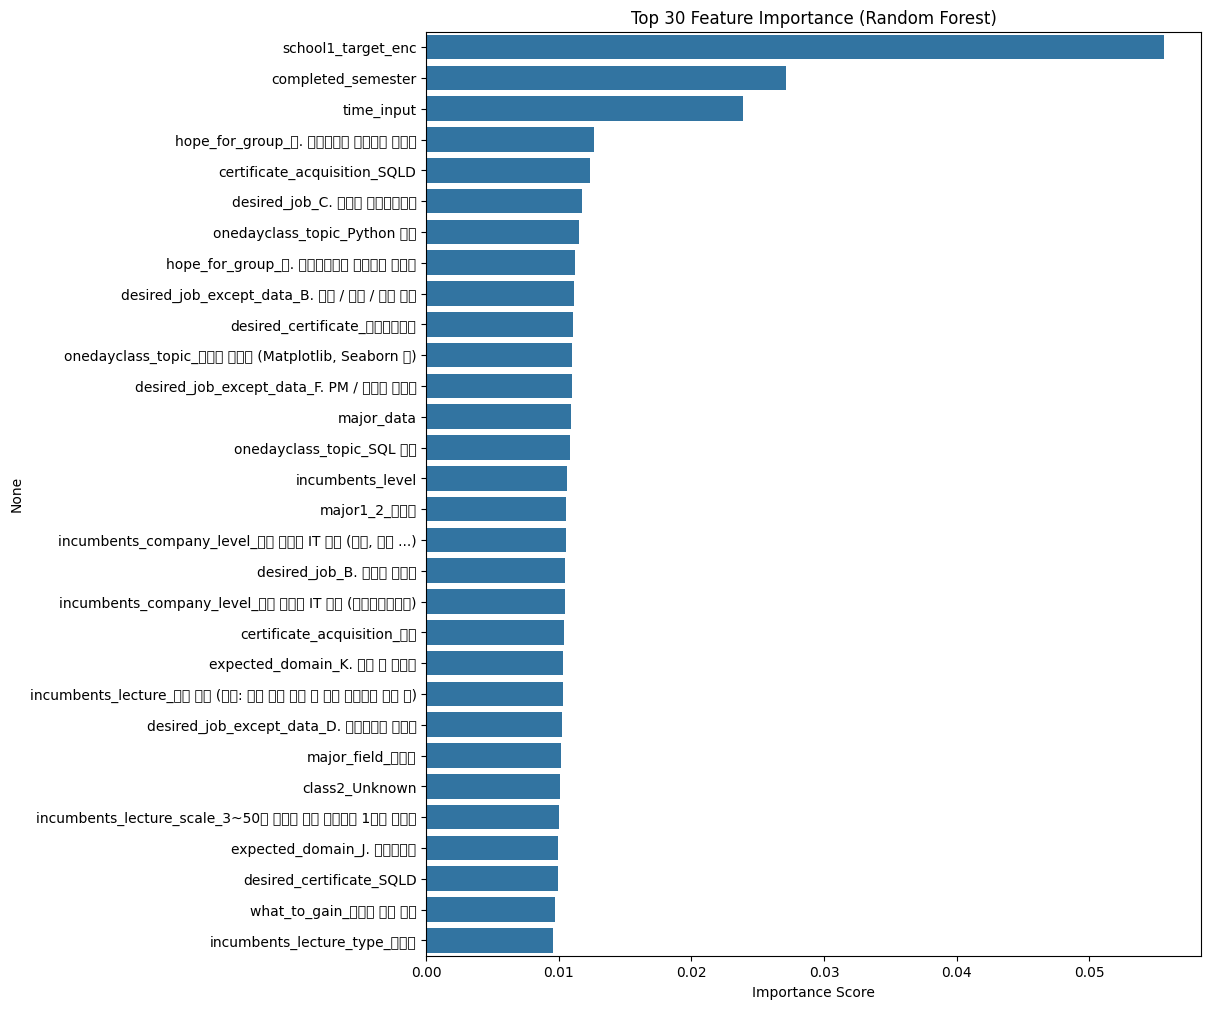

=== Top 30 Features ===
school1_target_enc                                        0.055676
completed_semester                                        0.027112
time_input                                                0.023883
hope_for_group_네. 온라인으로 참여하고 싶어요                          0.012667
certificate_acquisition_SQLD                              0.012373
desired_job_C. 데이터 사이언티스트                                 0.011753
onedayclass_topic_Python 응용                               0.011483
hope_for_group_네. 오프라인으로 참여하고 싶어요                         0.011198
desired_job_except_data_B. 기획 / 전략 / 경영 직무                0.011127
desired_certificate_정보처리기사                                0.011038
onedayclass_topic_데이터 시각화 (Matplotlib, Seaborn 등)         0.011029
desired_job_except_data_F. PM / 서비스 기획자                   0.010956
major_data                                                0.010918
onedayclass_topic_SQL 응용                                  0.010878
incumbents_level                      

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. 중요도 분석을 위한 임시 학습 데이터셋 정의
# (df_all을 훼손하지 않고, 정답(completed)이 있는 train 데이터만 슬라이싱하여 사용)
train_subset = df_all[df_all['dataset'] == 'train'].copy()

# 2. 불필요한 컬럼 제외 (dataset, ID 등 식별자, 타겟 변수)
# 사용자가 삭제하지 않은 ID나 기타 object 컬럼이 있다면 여기서 drop에 추가해야 에러가 안 납니다.
X_temp = train_subset.drop(columns=['completed', 'dataset']) 
y_temp = train_subset['completed']

# 3. 모델 학습 (가볍게 100그루만)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_temp, y_temp)

# 4. 중요도 추출 및 정렬
importances = pd.Series(rf.feature_importances_, index=X_temp.columns)
top30_features = importances.sort_values(ascending=False).head(30)

# 5. 시각화
plt.figure(figsize=(10, 12))
sns.barplot(x=top30_features.values, y=top30_features.index)
plt.title('Top 30 Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

# 텍스트로도 출력
print("=== Top 30 Features ===")
print(top30_features)


In [27]:
# df_all은 너무 크고 test데이터는 정답이 없으니, X_temp(train의 feature들) 사용
# 상관계수 행렬 계산
corr_mat = X_temp.corr().abs()

# 대각선 위쪽만 선택 (중복 제거)
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

# 상관계수가 0.95보다 큰 변수 찾기
high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"다중공선성 의심 변수 ({len(high_corr_cols)}개):")
print(high_corr_cols)


다중공선성 의심 변수 (5개):
['inflow_route_기존 학회원 또는 운영진', 'whyBDA_이전 기수에 매우 만족해서', 'previous_class_6_Unknown', 'previous_class_7_Unknown', 'previous_class_8_Unknown']


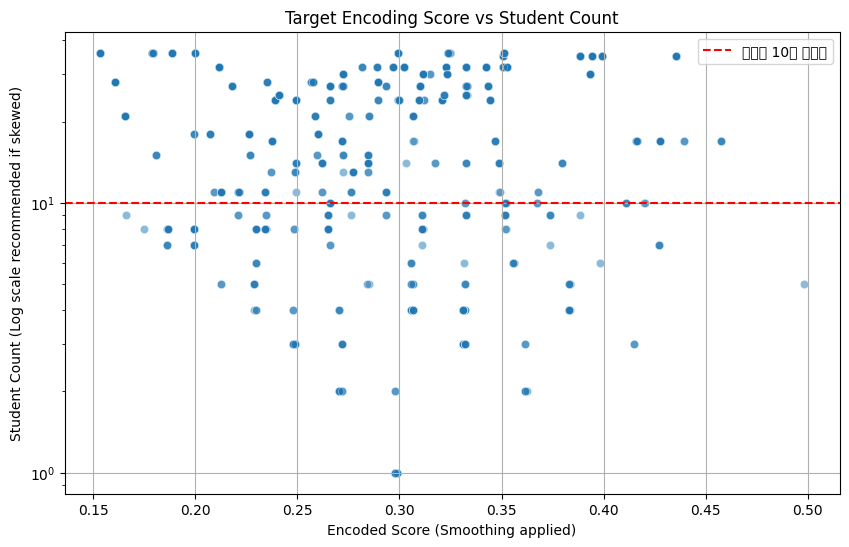

상위 10% 점수(0.3798 이상)를 받은 데이터들의 평균 학생 수:
-> 21.1명

[진단 기준]
- 점수가 높은데(X축 우측), 학생 수가 바닥(Y축 하단)에 깔린 점들이 많다면?
-> 과적합(Overfitting) 가능성 매우 높음. m(스무딩 파라미터) 값을 키워야 함.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 주의: 앞선 코드에서 df_all의 'school1' 원본 컬럼을 drop 했다면, 
# 원본 train 데이터를 다시 불러오거나 백업된 데이터를 사용해야 합니다.
# 여기서는 train 변수(원본)가 메모리에 있다고 가정하고 코드를 작성합니다.

# 1. 검증용 데이터프레임 생성 (학교별 수치 계산)
# train 데이터만 사용해야 정확한 '학습 시점'의 왜곡을 볼 수 있습니다.
school_stats = train.groupby('school1').agg(
    student_count=('completed', 'count'),       # 학교별 학생 수
    mean_completed=('completed', 'mean')        # 단순 수료율
).reset_index()

# 2. df_all에 있는 'school1_target_enc' 값을 가져오기 위해 매핑
# (학교명이 같은 행 하나씩만 뽑아서 매핑 테이블 생성)
mapping_table = df_all[df_all['dataset']=='train'][['school1_target_enc']].copy()
# df_all에는 school1 원본이 없으므로, train의 인덱스와 매칭하거나 
# 만약 df_all에 school1 원본을 남겨뒀다면 바로 groupby 하면 됨.
# **가장 확실한 방법: train 데이터에 동일한 로직으로 스무딩 값을 다시 계산해서 비교**

# (약식 확인법) 인코딩된 값(Score)별로 학생 수의 평균을 봅니다.
# 만약 Score가 높은 구간(예: 0.9 이상)의 평균 학생 수가 매우 적다면 왜곡된 것입니다.

# df_all에서 인코딩된 컬럼과 원본 train을 인덱스로 매칭 (순서가 안 섞였다면)
comparison_df = pd.DataFrame({
    'student_count': train.groupby('school1')['completed'].transform('count'),
    'encoded_score': df_all.loc[df_all['dataset']=='train', 'school1_target_enc'].values,
    'completed': train['completed']
})

# 3. 시각화: 인코딩 점수(X) vs 학생 수(Y) 산점도
plt.figure(figsize=(10, 6))
sns.scatterplot(data=comparison_df, x='encoded_score', y='student_count', alpha=0.5)
plt.axhline(y=10, color='r', linestyle='--', label='학생수 10명 기준선') # 10명 미만 경계선
plt.title('Target Encoding Score vs Student Count')
plt.xlabel('Encoded Score (Smoothing applied)')
plt.ylabel('Student Count (Log scale recommended if skewed)')
plt.yscale('log') # 학생 수 차이가 크면 로그 스케일 적용
plt.legend()
plt.grid(True)
plt.show()

# 4. 수치로 확인: 점수가 상위 10%인 학교들의 평균 학생 수
top_10_percent_score = comparison_df['encoded_score'].quantile(0.9)
high_score_group = comparison_df[comparison_df['encoded_score'] >= top_10_percent_score]

print(f"상위 10% 점수({top_10_percent_score:.4f} 이상)를 받은 데이터들의 평균 학생 수:")
print(f"-> {high_score_group['student_count'].mean():.1f}명")

print("\n[진단 기준]")
print("- 점수가 높은데(X축 우측), 학생 수가 바닥(Y축 하단)에 깔린 점들이 많다면?")
print("-> 과적합(Overfitting) 가능성 매우 높음. m(스무딩 파라미터) 값을 키워야 함.")


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm
import pandas as pd
import numpy as np

def calculate_vif_filtered(df_input):
    """
    1. 모든 수치형 변수 VIF 계산
    2. 원-핫 인코딩된 변수 제외
    3. VIF 10 이상만 필터링
    """
    # 1. 수치형 데이터만 선택
    vif_data = df_input.select_dtypes(include=[np.number]).copy()
    vif_data = vif_data.astype(float)
    
    # 2. 원-핫 인코딩되었다고 판단되는 접두사(Prefix) 목록 정의
    # (이전 전처리 과정에서 get_dummies를 수행한 원본 컬럼명들)
    ohe_prefixes = [
        'class1_', 'job_', 'hope_for_group_', 'desired_career_path_', 'incumbents_lecture_type_', 
        'desired_job_except_data_', 'expected_domain_', 'what_to_gain_', 'incumbents_lecture_', 
        'incumbents_company_level_', 'inflow_route_', 'incumbents_lecture_scale_', 'whyBDA_', 
        'desired_certificate_', 'desired_job_', 'certificate_acquisition_', 'onedayclass_topic_', 
        'major_field_', 'major1_1_', 'major1_2_', 'class2_',
        'previous_class_6_', 'previous_class_7_', 'previous_class_8_'
    ]

    # 제외할 컬럼 식별
    # (컬럼명이 위 접두사 중 하나로 시작하면 제외)
    cols_to_exclude = [col for col in vif_data.columns if any(col.startswith(prefix) for prefix in ohe_prefixes)]
    
    # 3. 제외 대상이 아닌 '순수 수치형/이진 변수'만 남김
    target_cols = [col for col in vif_data.columns if col not in cols_to_exclude]
    
    # (주의) VIF 계산은 '제외된 변수'들을 아예 배제하고 계산할지, 
    # 아니면 계산은 다 하고 보여주는 것만 필터링할지 결정해야 함.
    # -> 다중공선성은 '전체 변수 간의 관계'이므로 계산은 '전체(vif_data)'로 하고, 출력만 필터링하는 것이 맞음.
    
    print(f"총 {len(vif_data.columns)}개 변수로 VIF 계산 후, 원-핫 인코딩 변수 제외하고 출력합니다.")
    print("-" * 60)
    
    vif_list = []
    
    # 전체 변수에 대해 계산 (시간 소요)
    for i in tqdm(range(len(vif_data.columns))):
        col_name = vif_data.columns[i]
        
        # 최적화: 출력 대상(target_cols)이 아니면 굳이 리스트에 담을 필요 없지만,
        # VIF 함수 특성상 i번째 컬럼을 y로 놓고 나머지를 X로 쓰기 때문에
        # target_cols에 속한 변수들의 VIF를 구하려면 전체 행렬이 필요함.
        
        # 여기서는 '출력 대상'인 경우에만 결과 리스트에 추가
        if col_name in target_cols:
            try:
                vif = variance_inflation_factor(vif_data.values, i)
                vif_list.append({'Feature': col_name, 'VIF': vif})
            except Exception as e:
                vif_list.append({'Feature': col_name, 'VIF': 99999})

    # 4. 데이터프레임 변환
    vif_df = pd.DataFrame(vif_list)
    
    # 5. VIF 10 이상 필터링
    vif_df_high = vif_df[vif_df['VIF'] >= 10].sort_values(by='VIF', ascending=False).reset_index(drop=True)
    
    return vif_df_high

# [실행부]
# 1. Train 데이터 준비
if 'dataset' in df_all.columns:
    X_vif_check = df_all[df_all['dataset'] == 'train'].drop(columns=['completed', 'dataset'])
else:
    X_vif_check = df_all.drop(columns=['completed']) if 'completed' in df_all.columns else df_all

# 2. 함수 호출
final_vif_result = calculate_vif_filtered(X_vif_check)

# 3. 결과 출력
pd.set_option('display.max_rows', None)
print("\n" + "="*60)
print(f"=== [필터링 결과] VIF ≥ 10 인 주요 변수 (OHE 제외) ===")
print("="*60)

if final_vif_result.empty:
    print("✅ VIF가 10 이상인 주요 변수가 없습니다. (다중공선성 문제 없음)")
else:
    print(final_vif_result)
    print("-" * 60)
    print("※ inf: 다른 변수들과 완벽한 선형 관계 (즉시 조치 필요)")
    print("※ 10 이상: 다중공선성 높음 (제거 고려)")

pd.reset_option('display.max_rows')




총 181개 변수로 VIF 계산 후, 원-핫 인코딩 변수 제외하고 출력합니다.
------------------------------------------------------------


100%|██████████| 181/181 [00:00<00:00, 284.69it/s]


=== [필터링 결과] VIF ≥ 10 인 주요 변수 (OHE 제외) ===
           Feature        VIF
0  re_registration        inf
1       major type  11.362634
------------------------------------------------------------
※ inf: 다른 변수들과 완벽한 선형 관계 (즉시 조치 필요)
※ 10 이상: 다중공선성 높음 (제거 고려)


In [30]:
# =========================================================
# [최종] 다중공선성 높은 변수 제거 (VIF > 10)
# =========================================================

# 1. 제거할 변수 목록 정의
cols_to_remove_vif = ['re_registration', 'major type']

# 2. 실제로 존재하는 변수만 골라내기 (에러 방지)
real_remove_cols = [col for col in cols_to_remove_vif if col in df_all.columns]

if len(real_remove_cols) > 0:
    print(f"🚀 VIF가 높은 변수 제거 시작: {real_remove_cols}")
    
    # 3. 변수 제거 수행
    df_all = df_all.drop(columns=real_remove_cols)
    
    print("✅ 제거 완료!")
    print(f"   - 제거된 컬럼: {real_remove_cols}")
    print(f"   - 현재 남은 컬럼 수: {df_all.shape[1]}")
else:
    print("⚠️ 제거할 변수가 데이터프레임에 존재하지 않습니다. 이미 삭제되었거나 이름을 확인해주세요.")

# 4. 최종 데이터 확인 (선택 사항)
print("-" * 50)
print(f"📊 최종 모델링용 데이터 크기: {df_all.shape}")


🚀 VIF가 높은 변수 제거 시작: ['re_registration', 'major type']
✅ 제거 완료!
   - 제거된 컬럼: ['re_registration', 'major type']
   - 현재 남은 컬럼 수: 181
--------------------------------------------------
📊 최종 모델링용 데이터 크기: (1562, 181)


# 모델 학습 및 예측

[I 2026-02-16 23:21:39,462] A new study created in memory with name: no-name-e403f14d-eb4f-4d9c-b605-5295ec81fccb


📌 데이터 준비 완료
   - Train X: (748, 179), y: (748,)
   - Test X: (814, 179)
--------------------------------------------------
🚀 [XGBoost] Optuna 튜닝 시작 (30회)...


[I 2026-02-16 23:21:42,447] Trial 0 finished with value: 0.37871124073496965 and parameters: {'n_estimators': 437, 'max_depth': 10, 'learning_rate': 0.22227824312530747, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_alpha': 0.5808361216819946, 'reg_lambda': 8.661761457749352, 'scale_pos_weight': 6.41003510568888}. Best is trial 0 with value: 0.37871124073496965.
[I 2026-02-16 23:21:47,823] Trial 1 finished with value: 0.3916066333819628 and parameters: {'n_estimators': 737, 'max_depth': 3, 'learning_rate': 0.29127385712697834, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'gamma': 0.9091248360355031, 'reg_alpha': 1.8340450985343382, 'reg_lambda': 3.0424224295953772, 'scale_pos_weight': 5.72280788469014}. Best is trial 1 with value: 0.3916066333819628.
[I 2026-02-16 23:21:51,460] Trial 2 finished with value: 0.35376709748226776 and parameters: {'n_estimators': 489, 'max_depth': 5, 'learning_rate': 0.

✅ XGB Best F1: 0.4559

🚀 [CatBoost] Optuna 튜닝 시작 (30회)...


[I 2026-02-16 23:25:33,208] Trial 0 finished with value: 0.16269550549949274 and parameters: {'iterations': 437, 'depth': 10, 'learning_rate': 0.22227824312530747, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'scale_pos_weight': 2.403950683025824}. Best is trial 0 with value: 0.16269550549949274.
[I 2026-02-16 23:25:43,517] Trial 1 finished with value: 0.34030775331031954 and parameters: {'iterations': 152, 'depth': 9, 'learning_rate': 0.18432335340553055, 'l2_leaf_reg': 7.372653200164409, 'border_count': 36, 'scale_pos_weight': 9.72918866945795}. Best is trial 1 with value: 0.34030775331031954.
[I 2026-02-16 23:25:52,266] Trial 2 finished with value: 0.3629872043665147 and parameters: {'iterations': 850, 'depth': 4, 'learning_rate': 0.06272924049005918, 'l2_leaf_reg': 2.650640588680904, 'border_count': 100, 'scale_pos_weight': 5.72280788469014}. Best is trial 2 with value: 0.3629872043665147.
[I 2026-02-16 23:25:58,611] Trial 3 finished with value: 0.27363670562864467 and par

✅ Cat Best F1: 0.4593

🚀 최종 모델 학습 및 예측 (Soft Voting)
✅ 예측 완료!


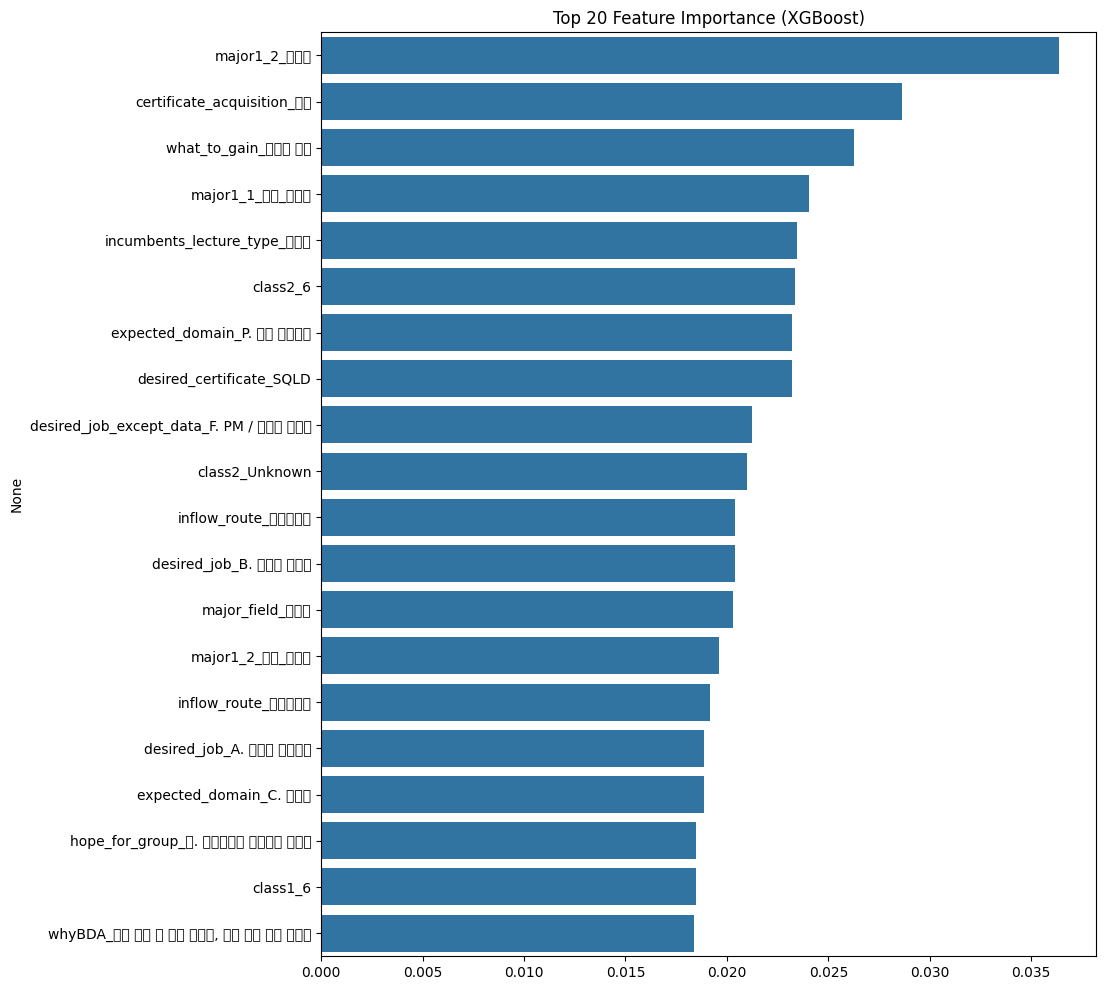

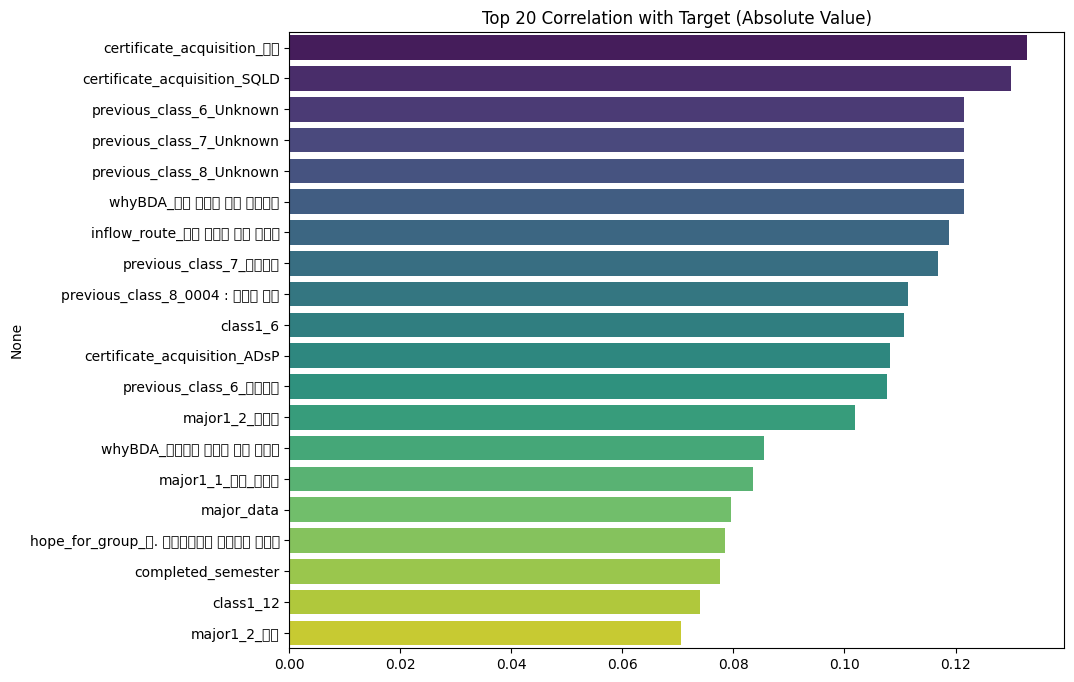


🎉 저장 완료: ../submit\hmw0216_0.458.csv
         ID  completed
0  TEST_000          1
1  TEST_001          1
2  TEST_002          1
3  TEST_003          1
4  TEST_004          1


In [31]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. 데이터 준비 (전처리 완료된 df_all 사용)
# =========================================================

# (1) Train / Test 분리
# Test 데이터에는 타겟 변수(completed)가 없으므로 제외하고 분리
train_final = df_all[df_all['dataset'] == 'train'].drop(columns=['dataset'])
test_final = df_all[df_all['dataset'] == 'test'].drop(columns=['dataset', 'completed'])

# (2) X, y 정의
X = train_final.drop(columns=['completed'])
y = train_final['completed'].astype(int)

# (3) 컬럼 순서 및 개수 일치 확인 (필수)
X_test = test_final[X.columns] # Train과 동일한 순서로 정렬

print(f"📌 데이터 준비 완료")
print(f"   - Train X: {X.shape}, y: {y.shape}")
print(f"   - Test X: {X_test.shape}")
print("-" * 50)


# =========================================================
# 2. Optuna를 활용한 하이퍼파라미터 튜닝 함수
# =========================================================
def objective_xgb(trial):
    """XGBoost 하이퍼파라미터 튜닝"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10), # 불균형 대응
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss' # F1 최적화를 위해 logloss 사용 (이진분류)
    }
    
    # 5-Fold Stratified CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, verbose=False)
        
        preds = model.predict(X_val)
        f1 = f1_score(y_val, preds, average='binary') # Binary F1
        f1_scores.append(f1)
        
    return np.mean(f1_scores)

def objective_cat(trial):
    """CatBoost 하이퍼파라미터 튜닝"""
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'random_seed': 42,
        'verbose': 0,
        'allow_writing_files': False
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        f1 = f1_score(y_val, preds, average='binary')
        f1_scores.append(f1)
        
    return np.mean(f1_scores)


# =========================================================
# 3. 튜닝 실행 (시간 관계상 N_TRIALS 조정 가능)
# =========================================================
N_TRIALS = 30 # (빠르게 테스트하려면 줄이세요)

print(f"🚀 [XGBoost] Optuna 튜닝 시작 ({N_TRIALS}회)...")
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)
best_params_xgb = study_xgb.best_params
print(f"✅ XGB Best F1: {study_xgb.best_value:.4f}")

print(f"\n🚀 [CatBoost] Optuna 튜닝 시작 ({N_TRIALS}회)...")
study_cat = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=N_TRIALS)
best_params_cat = study_cat.best_params
print(f"✅ Cat Best F1: {study_cat.best_value:.4f}")


# =========================================================
# 4. 최종 모델 학습 및 앙상블 (Soft Voting)
# =========================================================
print("\n" + "="*50)
print("🚀 최종 모델 학습 및 예측 (Soft Voting)")
print("="*50)

# (1) 최적 파라미터로 전체 데이터 재학습
final_xgb = xgb.XGBClassifier(**best_params_xgb, random_state=42, n_jobs=-1)
final_cat = CatBoostClassifier(**best_params_cat, random_seed=42, verbose=0, allow_writing_files=False)

final_xgb.fit(X, y)
final_cat.fit(X, y)

# (2) Test 데이터에 대한 확률 예측
prob_xgb = final_xgb.predict_proba(X_test)[:, 1]
prob_cat = final_cat.predict_proba(X_test)[:, 1]

# (3) 앙상블 (단순 평균) - 가중치 조절 가능 (예: 0.6 * xgb + 0.4 * cat)
final_prob = (prob_xgb + prob_cat) / 2

# (4) 최종 클래스 결정 (Threshold 0.5)
final_pred = (final_prob >= 0.5).astype(int)

print("✅ 예측 완료!")


# =========================================================
# 5. Feature Importance & 상관계수 시각화
# =========================================================
# (1) Feature Importance (XGBoost 기준)
plt.figure(figsize=(10, 12))
importances = pd.Series(final_xgb.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)
sns.barplot(x=top20.values, y=top20.index)
plt.title('Top 20 Feature Importance (XGBoost)')
plt.show()

# (2) 종속변수 상관계수 시각화 (Top 20)
# (이미 전처리된 X에 y를 붙여서 계산)
temp_df = X.copy()
temp_df['target'] = y
corr_series = temp_df.corr()['target'].drop('target').abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_series.values, y=corr_series.index, palette='viridis')
plt.title('Top 20 Correlation with Target (Absolute Value)')
plt.show()


# =========================================================
# 6. 결과 파일 저장
# =========================================================
# (1) 경로 설정
submit_dir = "../submit"
if not os.path.exists(submit_dir):
    os.makedirs(submit_dir)

# (2) 파일명 생성 (hmw오늘날짜_점수)
# 점수는 CV에서 나온 최고 점수 평균을 사용하거나 000으로 표시
# 여기서는 XGB와 Cat의 CV 최고점수 평균을 파일명에 기재
avg_cv_score = (study_xgb.best_value + study_cat.best_value) / 2
today_str = datetime.datetime.now().strftime("%m%d")
file_name = f"hmw{today_str}_{avg_cv_score:.3f}.csv"
save_path = os.path.join(submit_dir, file_name)

# (3) submission 파일 생성
# sample_submission 로드 (경로 주의: 사용 환경에 맞게 수정 필요)
# 여기서는 첨부해주신 파일명 기준
try:
    sub = pd.read_csv("sample_submission.csv") # 같은 폴더에 있다고 가정
except FileNotFoundError:
    sub = pd.read_csv("../datasets/sample_submission.csv") # 상위 폴더 가정

# ID는 submission 파일의 ID 순서를 따름 (혹시 순서가 섞였을까봐 merge 사용 추천)
# 하지만 보통 순서가 같으므로 직접 대입
sub['completed'] = final_pred

# (4) 저장
sub.to_csv(save_path, index=False)

print(f"\n🎉 저장 완료: {save_path}")
print(sub.head())
